Robot: Simulates the Franka Emika Panda robotic arm for manipulation tasks.

Observation Space:

All tasks include gripper position and velocity (6 values).
Tasks involving objects include their position, orientation, and velocities (linear and rotational, 12 values per object).
Gripper opening (distance between fingers) is included if not constrained closed (1 value).
Action Space:

Gripper movement commands (3 values for x, y, and z axes).
Gripper opening/closing command (1 value).
Simulation Details:

Simulation runs 20 timesteps per agent action (2ms each).
Overall interaction frequency is 25Hz.
Most tasks have episodes lasting 2 seconds (50 interactions).
Reward Function:

Default reward is sparse: 0 for successful completion (within 5cm tolerance), -1 otherwise.
Sparse rewards are simpler to define but lack information on progress.

# Experiment: Inverse Reinforcement Learning vs GAIL Comparison

## 1. Objective
This experiment aims to compare two different approaches for learning from demonstration in a robotic manipulator task (`PandaReach-v3`):
1.  **Inverse Reinforcement Learning (IRL)**: using the Projection Method to infer a reward function.
2.  **Generative Adversarial Imitation Learning (GAIL)**: learning a policy directly from data using adversarial training.

## 2. Experimental Setup
The experiment consists of three main phases:

### Phase 1: Expert Training (Base-line)
- **Algorithm**: Twin Delayed DDPG (TD3)
- **Goal**: Train a high-performance agent (Expert) to solve the task using the ground-truth environment reward.
- **Output**: A trained expert observation model and a dataset of expert trajectories.

### Phase 2: Apprentice Training
Two types of apprentices are trained to mimic the expert's behavior without access to the ground-truth reward:

**A. TD3 Apprentices (IRL - Projection Method)**
- **Method**: Iteratively infers a reward function $R(s) = w^T \phi(s)$ that explains the expert's feature expectations.
- **Process**:
  1.  Apprentice 0 is trained with random weights.
  2.  New weights are computed to maximize the margin between expert and apprentice features.
  3.  Apprentice $i$ is trained using TD3 with the inferred reward $R(s)$.
- **Agents**: Apprentices 0 to 3.

**B. GAIL Apprentices (Imitation Learning)**
- **Method**: Uses a Discriminator to distinguish between expert and apprentice state-action pairs.
- **Reward**: A synthetic reward $r = -\log(1 - D(s,a))$ prompts the agent to behave like the expert.
- **Agents**: Apprentices 1 to 3.

### Phase 3: Evaluation & Comparison
All agents are evaluated on standard metrics to determine which method better recovers the expert's performance:
- **Success Rate**: Percentage of episodes where the target is reached.
- **Mean Return**: Average cumulative reward (from the original environment).

# TD3 vs GAIL Comparison

This notebook compares TD3 (with IRL projection method) and GAIL for training Apprentice agents.
- **Expert**: Trained using TD3
- **TD3 Apprentice 0-3**: Trained using projection method IRL
- **GAIL Apprentice 1-3**: Trained using GAIL imitation learning

In [1]:
# Imports
import config
import td3_runner
import gail_runner
from plotting import plot_comparative_dashboard, plot_cross_algorithm_comparison

## 1. TD3 Expert Training

### Reinforcement Learning Implementation (TD3)

* **Reinforcement Learning (RL)** is a framework where an agent learns to make decisions by interacting with an environment. The goal is to learn a policy $\pi$ that maximizes the expected cumulative reward:
  $$ J(\pi) = \mathbb{E}_{\pi} \left[ \sum_{t=0}^T \gamma^t r(s_t, a_t) \right] $$

* **Actor-Critic Architecture**:
  * **Actor ($\pi_\theta$)**: Decides which action to take in a given state.
  * **Critic ($Q_\phi$)**: Estimates the value (expected future reward) of taking that action.

* **Twin Delayed DDPG (TD3)**:
  TD3 is an advanced Actor-Critic algorithm that improves upon DDPG by reducing function approximation error (overestimation bias). It achieves this using:
  1.  **Clipped Double Q-Learning**: Uses two critics and takes the minimum value.
  2.  **Delayed Policy Updates**: Updates the actor less frequently than the critic.
  3.  **Target Policy Smoothing**: Adds noise to target actions to regularize the value estimate.


### Twin Delayed Deep Deterministic Policy Gradient (TD3)

TD3 is an off-policy actor-critic algorithm that addresses estimation errors in DDPG.

**Algorithm Steps:**

1. **Initialization:**
   - Initialize critic networks $Q_{\phi_1}, Q_{\phi_2}$ and actor network $\pi_\theta$ with random parameters.
   - Initialize target networks $\phi'_1 \leftarrow \phi_1, \phi'_2 \leftarrow \phi_2, \theta' \leftarrow \theta$.
   - Initialize replay buffer $\mathcal{B}$.

2. **Interaction:**
   - Select action with exploration noise $a \sim \pi_\theta(s) + \epsilon$, observe reward $r$ and new state $s'$, store transition in $\mathcal{B}$.

3. **Training:**
   - Sample mini-batch of $N$ transitions $(s, a, r, s', d)$ from $\mathcal{B}$.

4. **Target Action Smoothing:**
   - Compute target action with clipped noise to smooth value estimates:
     $$ \tilde{a} \leftarrow \text{clip}(\pi_{\theta'}(s') + \epsilon, a_{\text{min}}, a_{\text{max}}), \quad \epsilon \sim \text{clip}(\mathcal{N}(0, 0.2), -0.5, 0.5) $$

5. **Target Q-Value Calculation:**
   - Compute target Q-value using the minimum of the two target critics (Clipped Double Q-Learning):
     $$ y \leftarrow r + \gamma \min_{i=1,2} Q_{\phi'_i}(s', \tilde{a}) (1 - d) $$

6. **Critic Update:**
   - Update critics by minimizing the Mean Squared Error (MSE) loss:
     $$ L = \frac{1}{N} \sum (y - Q_{\phi_i}(s,a))^2 $$

7. **Actor Update (Delayed):**
   - If current step $t \mod d = 0$ (default $d=2$), update $\theta$ by deterministic policy gradient:
     $$ \nabla_\theta J(\theta) \approx \frac{1}{N} \sum \nabla_a Q_{\phi_1}(s, a)|_{a=\pi_\theta(s)} \nabla_\theta \pi_\theta(s) $$
   - Update target networks using soft updates:
     $$ \theta' \leftarrow \tau \theta + (1-\tau)\theta' $$
     $$ \phi'_i \leftarrow \tau \phi_i + (1-\tau)\phi'_i $$

**Symbol Definitions:**
- $s, a, r, s'$: State, Action, Reward, Next State
- $d$: Done flag (1 if episode terminated, else 0)
- $\pi_\theta$: Actor network with parameters $\theta$
- $Q_{\phi_i}$: Critic networks $(i=1,2)$ with parameters $\phi_i$
- $\theta', \phi'_i$: Target network parameters
- $\epsilon$: Exploration noise (Action noise) or Smoothing noise
- $\gamma$: Discount factor (0.99)
- $\tau$: Soft update coefficient (0.05)
- $\mathcal{B}$: Replay buffer
- $N$: Batch size (256)



pybullet build time: Dec  5 2025 16:32:26


argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color_green=0.21176470816135406
argv[2]=--background_color_blue=0.1764705926179886
startThreads creating 1 threads.
starting thread 0
started thread 0 
argc=5
argv[0] = --unused
argv[1] = --background_color_red=0.8745098114013672
argv[2] = --background_color_green=0.21176470816135406
argv[3] = --background_color_blue=0.1764705926179886
argv[4] = --start_demo_name=Physics Server
ExampleBrowserThreadFunc started
X11 functions dynamically loaded using dlopen/dlsym OK!
X11 functions dynamically loaded using dlopen/dlsym OK!
Creating context
Created GL 3.3 context
Direct GLX rendering context obtained
Making context current
GL_VENDOR=Mesa
GL_RENDERER=llvmpipe (LLVM 20.1.2, 256 bits)
GL_VERSION=4.5 (Core Profile) Mesa 25.0.7-0ubuntu0.24.04.2
GL_SHADING_LANGUAGE_VERSION=4.50
pthread_getconcurrency()=0
Version = 4.5 (Core Profile) Mesa 25.0.7-0ubuntu0.24.04.2
Vendor = Mesa
Renderer = llvmpipe (LLVM 20.1.2, 256 bits)
b3Print

Training..:  10%|█         | 51/500 [00:13<02:03,  3.65it/s]

Episode: 50 	 Steps: 50 	 Score: -50.0 	 Recent Avg Score: -47.1 	 Success: 3/50 (6.0%)


Training..:  20%|██        | 101/500 [00:24<00:53,  7.43it/s]

...

Training..:  80%|████████  | 402/500 [00:57<00:09, 10.21it/s]

Episode: 400 	 Steps: 3 	 Score: -2.0 	 Recent Avg Score: -2.0 	 Success: 50/50 (100.0%)


Training..:  90%|█████████ | 452/500 [01:03<00:05,  9.48it/s]

Episode: 450 	 Steps: 5 	 Score: -4.0 	 Recent Avg Score: -2.0 	 Success: 50/50 (100.0%)


Training..: 100%|██████████| 500/500 [01:08<00:00,  7.29it/s]


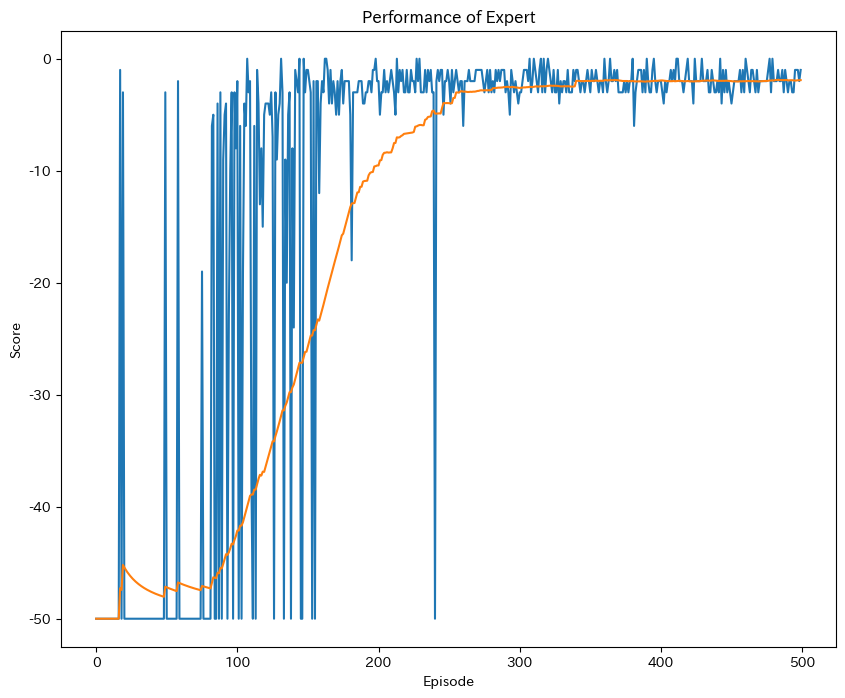

Expert model saved to /home/shimoiyusuke/manipulator-inverse-rl/Compare/Models/Expert

--- TD3 Expert Stats (per 50 episodes) ---
Chunk  Range           Success    Fail       Rate      
------------------------------------------------------------
0      0-49            3.0        47.0         6.00%
1      50-99           14.0       36.0        28.00%
2      100-149         41.0       9.0         82.00%
3      150-199         48.0       2.0         96.00%
4      200-249         49.0       1.0         98.00%
5      250-299         50.0       0.0        100.00%
6      300-349         50.0       0.0        100.00%
7      350-399         50.0       0.0        100.00%
8      400-449         50.0       0.0        100.00%
9      450-499         50.0       0.0        100.00%



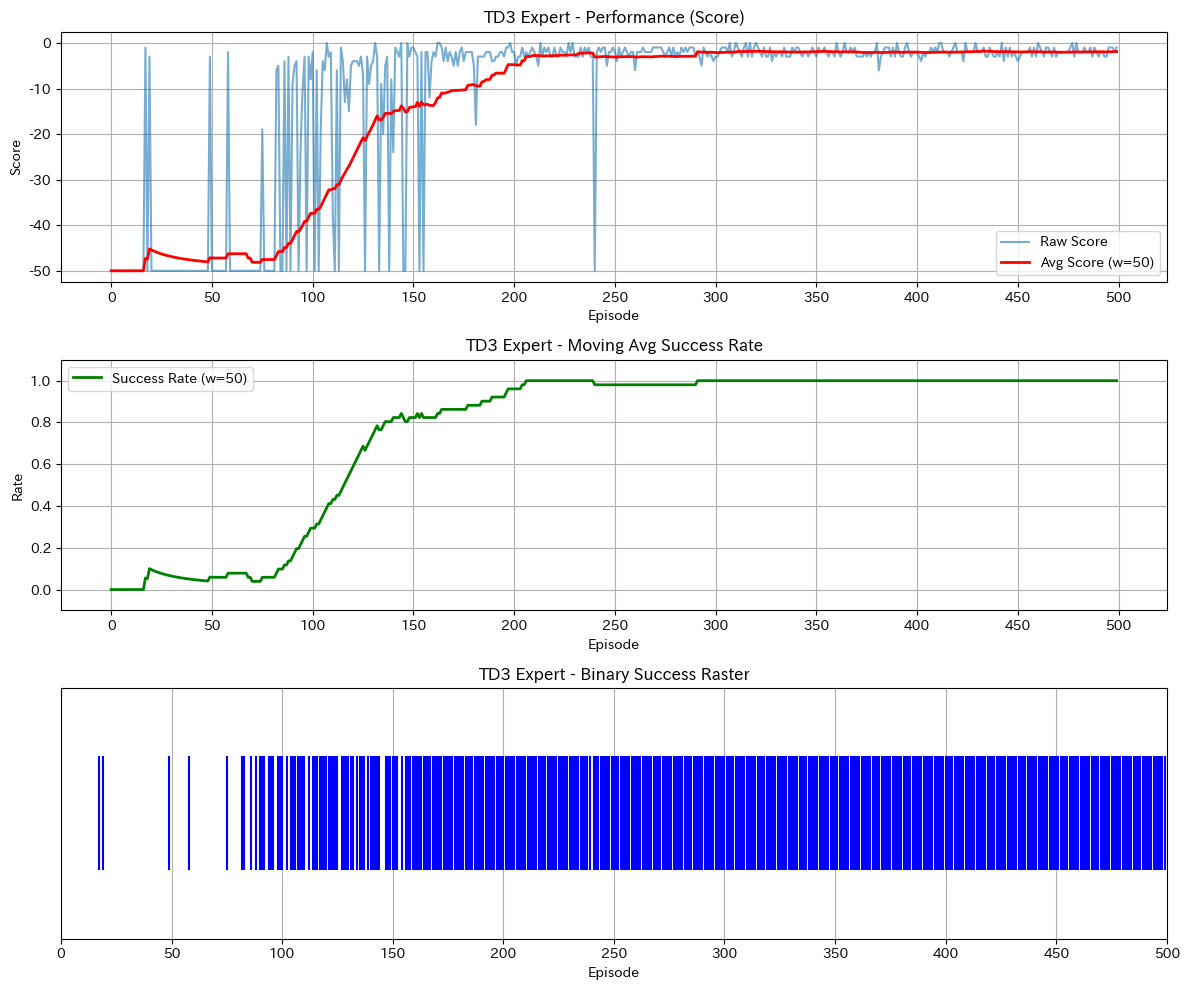

In [2]:
# Train TD3 Expert
td3_expert, td3_expert_train_data = td3_runner.train_expert()

## 2. TD3 Expert Evaluate


### Evaluation Algorithm

The Expert agent is evaluated over $M=500$ episodes.

**1. Stochastic Policy:**
Unlike standard evaluation which is often deterministic, this implementation utilizes the exploration policy with Gaussian noise:
$$ a_t = \text{clip}(\pi_\theta(s_t) + \epsilon, a_{\text{min}}, a_{\text{max}}), \quad \epsilon \sim \mathcal{N}(0, 0.1) $$

**2. Metrics:**
- **Mean Return:** Average cumulative reward.
  $$ \bar{G} = \frac{1}{M} \sum_{i=1}^M G_i, \quad G_i = \sum_{t=0}^T r_t^{(i)} $$

- **Success Rate:** Percentage of episodes where the agent successfully reaches the target (distance < 5cm).
  $$ S = \frac{1}{M} \sum_{i=1}^M \mathbb{I}(\text{success}^{(i)}) \times 100 $$

**Symbol Definitions:**
- $M$: Total number of evaluation episodes (500)
- $G_i$: Cumulative return for episode $i$
- $T$: Total timesteps in an episode
- $r_t^{(i)}$: Reward at time prediction step $t$ in episode $i$
- $\mathbb{I}(\cdot)$: Indicator function (1 if condition is true, 0 otherwise)
- $\epsilon$: Gaussian noise sampled from $\mathcal{N}(0, 0.1)$



numActiveThreads = 0
stopping threads
Evaluating TD3 Expert over 500 episodes...
Evaluating agent for 500 episodes...
Thread with taskId 0 exiting
Thread TERMINATED
destroy semaphore
semaphore destroyed
destroy main semaphore
main semaphore destroyed
finished
numActiveThreads = 0
btShutDownExampleBrowser stopping threads
Thread with taskId 0 exiting
Thread TERMINATED
destroy semaphore
semaphore destroyed
destroy main semaphore
main semaphore destroyed
argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color_green=0.21176470816135406
argv[2]=--background_color_blue=0.1764705926179886
startThreads creating 1 threads.
starting thread 0
started thread 0 
argc=5
argv[0] = --unused
argv[1] = --background_color_red=0.8745098114013672
argv[2] = --background_color_green=0.21176470816135406
argv[3] = --background_color_blue=0.1764705926179886
argv[4] = --start_demo_name=Physics Server
ExampleBrowserThreadFunc started
X11 functions dynamically loaded using dlopen/dlsym OK!
X11

Evaluating:   0%|          | 2/500 [00:00<00:37, 13.27it/s]

ven = Mesa
ven = Mesa


Evaluating: 100%|██████████| 500/500 [00:13<00:00, 37.24it/s]


TD3 Expert Evaluation: Mean Return = -1.886, Std = 1.155, Success: 500/500 (100.0%)

--- TD3 Expert (Eval) Stats (per 50 episodes) ---
Chunk  Range           Success    Fail       Rate      
------------------------------------------------------------
0      0-49            50         0          100.00%
1      50-99           50         0          100.00%
2      100-149         50         0          100.00%
3      150-199         50         0          100.00%
4      200-249         50         0          100.00%
5      250-299         50         0          100.00%
6      300-349         50         0          100.00%
7      350-399         50         0          100.00%
8      400-449         50         0          100.00%
9      450-499         50         0          100.00%



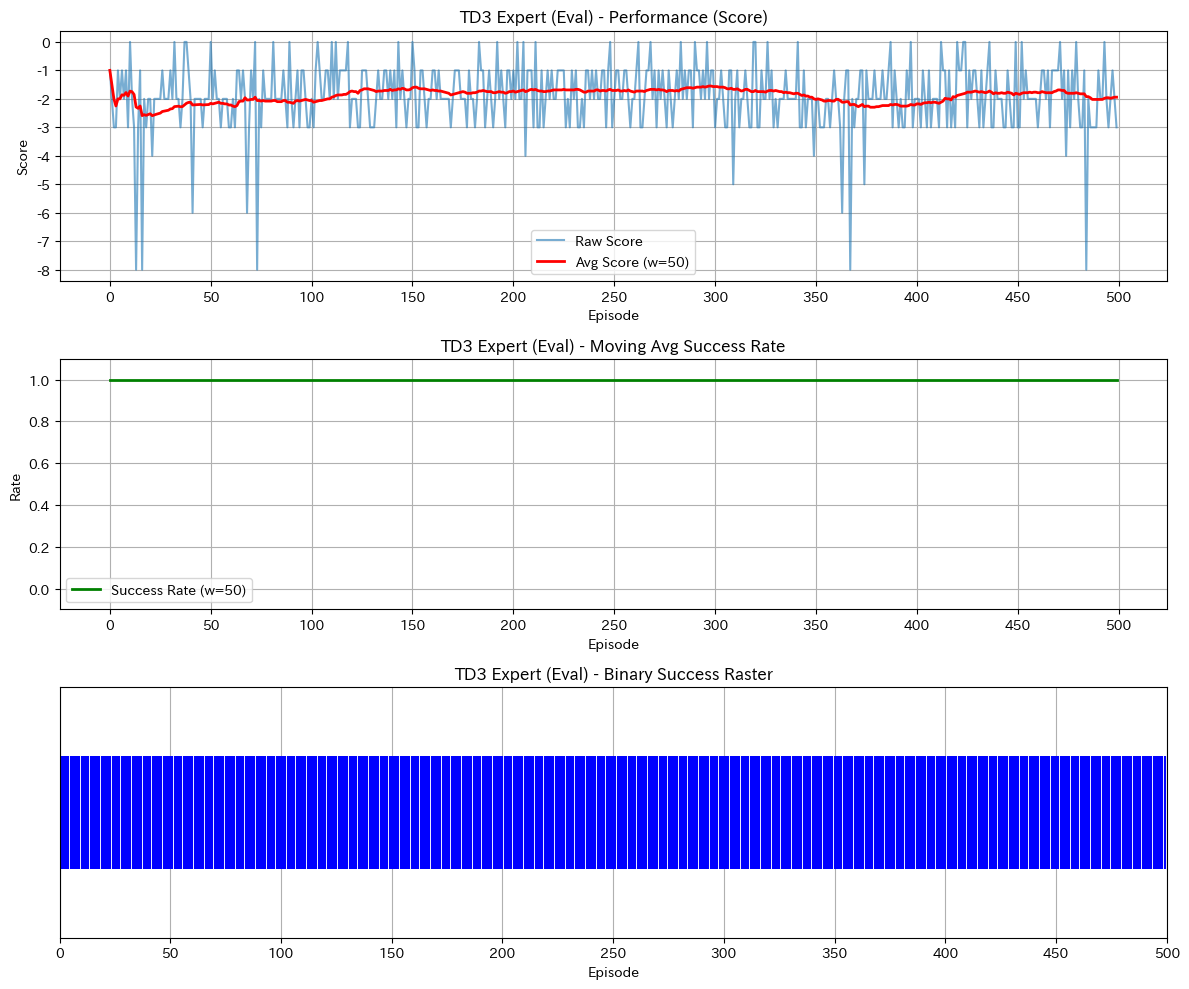

numActiveThreads = 0
stopping threads
Thread with taskId 0 exiting
Thread TERMINATED
destroy semaphore
semaphore destroyed
destroy main semaphore
main semaphore destroyed
finished
numActiveThreads = 0
btShutDownExampleBrowser stopping threads
Thread with taskId 0 exiting
Thread TERMINATED
destroy semaphore
semaphore destroyed
destroy main semaphore
main semaphore destroyed


In [3]:
# Evaluate TD3 Expert
td3_expert, td3_expert_eval_data = td3_runner.evaluate_expert(expert=td3_expert)

## 3. TD3 Apprentice Training (0-3)

## Inverse Reinforcement Learning (IRL)
* To train new agents, instead of utilizing the (predefined) returned reward from the training environment, it incorporates the reward function of the expert derived from the IRL algorithm. This reward function involves a weight term $(w)$ and observation space $(Φ(s))$ obtained through the IRL algorithm.

* Feature Expectations $(µ(π))$: The expected discounted accumulated feature vector for a policy $π$ (captures the long-term effects of a policy on state features).

* We can estimate the expert's feature expectations $(µE)$ from observed monte carlo trajectories.

* The empirical estimate for $µE = µ(πE)$ based on a set of $m$ observed expert trajectories is given by:

$$µ̂_E = \frac{1}{m} ∑_m ∑_t (γ^t * φ(ŝ(i)_t))$$


### Inverse Reinforcement Learning (Projection Method) for Apprentice Training

Apprentice agents are trained using Inverse Reinforcement Learning (IRL). unlike the Expert which learns from a sparse environment reward, Apprentices learn to optimize a reward function that explains the Expert's behavior.

**Theory & Algorithm:**

The goal is to find a policy $\pi$ whose feature expectations match those of the expert $\mu_E$. We use a game-theoretic approach (Projection Method) to iteratively find such a policy.

**1. Initialization:**
- **Apprentice 0:** We start with an initial policy $\pi^{(0)}$ (trained with random reward weights $w^{(0)}$).
- Compute its feature expectation $$\mu^{(0)} = \mathbb{E}_{\pi^{(0)}}\left[ \sum \gamma^t \phi(s_t) \right]$$
- Set iteration $i = 1$.

**2. Weight Computation (Projection):**
- We seek a new weight vector $w^{(i)}$ to maximize the margin between the expert's Feature Expectation and the current set of apprentice Feature Expectations.
- The weight vector determines the reward function for the next apprentice:
  $$ R_w(s) = (w^{(i)})^T \phi(s) $$

**3. Apprentice Training (TD3):**
- A new Apprentice agent (initialized from scratch) is trained using the **TD3 Algorithm** (see Section 1) to maximize the synthesized reward $R_w(s)$.
- The goal is to find optimal policy:
  $$ \pi^{(i)} = \arg\max_\pi \mathbb{E}_{\pi} \left[ \sum_{t=0}^T \gamma^t (w^{(i)})^T \phi(s_t) \right] $$

**4. Feature Expectation Update:**
- Estimate $\mu^{(i)}$ by Monte Carlo limit of expected features from $\pi^{(i)}$.
- Compute margin $t^{(i)}$:
  $$ t^{(i)} = \min_{j<i} (w^{(i)})^T (\mu_E - \mu^{(j)}) $$

**5. Termination:**
- If $t^{(i)} \le \epsilon_{\text{irl}}$, convergence is reached. Otherwise, $i \leftarrow i+1$ and repeat from Step 2.

**Symbol Definitions:**
- $\pi^{(i)}$: Policy of Apprentice $i$
- $\mu_E$: Feature expectations of the Expert
- $\mu^{(i)}$: Feature expectations of Apprentice $i$
- $\phi(s)$: Feature vector of state $s$ (Normalized observation + Goal info)
- $w^{(i)}$: Reward weight vector at iteration $i$
- $R_w(s)$: Synthesized reward function used for Apprentice training
- $\epsilon_{\text{irl}}$: Convergence threshold for the margin (0.001)
- $\gamma$: Discount factor (0.99)



argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color_green=0.21176470816135406
argv[2]=--background_color_blue=0.1764705926179886
startThreads creating 1 threads.
starting thread 0
Computing Expert feature expectation with 1000 episodes...
started thread 0 
argc=5
argv[0] = --unused
argv[1] = --background_color_red=0.8745098114013672
argv[2] = --background_color_green=0.21176470816135406
argv[3] = --background_color_blue=0.1764705926179886
argv[4] = --start_demo_name=Physics Server
ExampleBrowserThreadFunc started
X11 functions dynamically loaded using dlopen/dlsym OK!
X11 functions dynamically loaded using dlopen/dlsym OK!
Creating context
Created GL 3.3 context
Direct GLX rendering context obtained
Making context current
GL_VENDOR=Mesa
GL_RENDERER=llvmpipe (LLVM 20.1.2, 256 bits)
GL_VERSION=4.5 (Core Profile) Mesa 25.0.7-0ubuntu0.24.04.2
GL_SHADING_LANGUAGE_VERSION=4.50
pthread_getconcurrency()=0
Version = 4.5 (Core Profile) Mesa 25.0.7-0ubuntu0.24.04.2
Vendor

Computing features and rewards:   0%|          | 2/1000 [00:00<01:30, 11.00it/s]

ven = Mesa
ven = Mesa


Computing features and rewards: 100%|██████████| 1000/1000 [00:28<00:00, 35.25it/s]



Feature expectation:  tensor([[ 2.4799e-02, -2.5873e-04,  1.7449e-01, -1.9512e-01,  2.6808e-03,
         -2.6510e-01,  2.4799e-02, -2.5873e-04,  1.7449e-01,  1.6473e-03,
          4.9841e-04,  1.5183e-01]], device='cuda:0')

Mean reward:  -1.982

  TD3 Apprentice 0 Training



Training..:  51%|█████     | 51/100 [00:14<00:14,  3.39it/s]

Episode: 50 	 Steps: 50 	 Score: -320.6 	 Recent Avg Score: -287.7 	 Success: 5/50 (10.0%)


Training..: 100%|██████████| 100/100 [00:28<00:00,  3.48it/s]


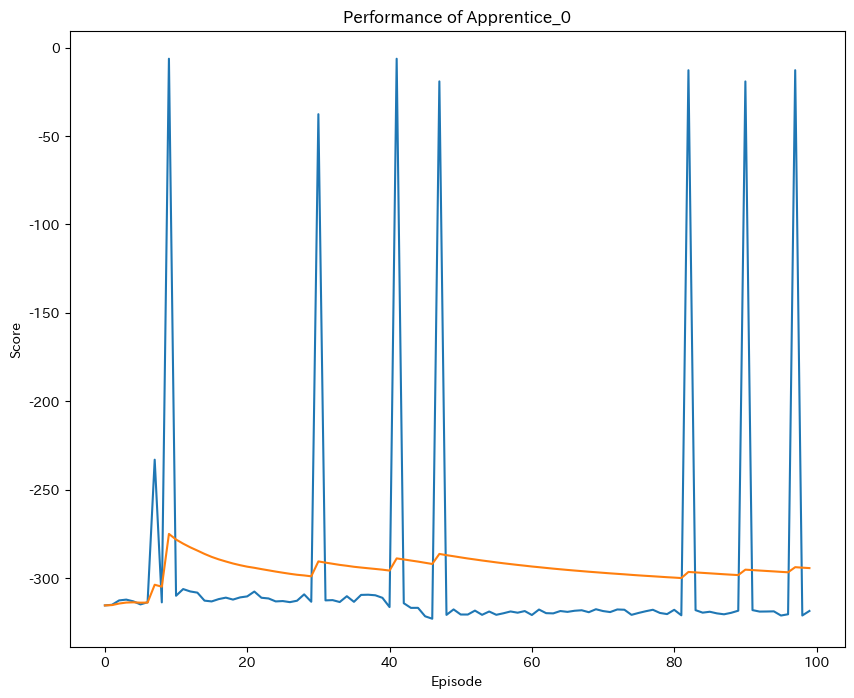

Computing features and rewards: 100%|██████████| 1000/1000 [01:49<00:00,  9.15it/s]



Feature expectation:  tensor([[-0.6688,  0.4146,  0.5339, -0.2732,  0.1761,  0.1620, -0.6688,  0.4146,
          0.5339,  0.0018, -0.0009,  0.1504]], device='cuda:0')

Mean reward:  -47.798

--- TD3 Apprentice 0 Stats (per 50 episodes) ---
Chunk  Range           Success    Fail       Rate      
------------------------------------------------------------
0      0-49            5.0        45.0        10.00%
1      50-99           3.0        47.0         6.00%



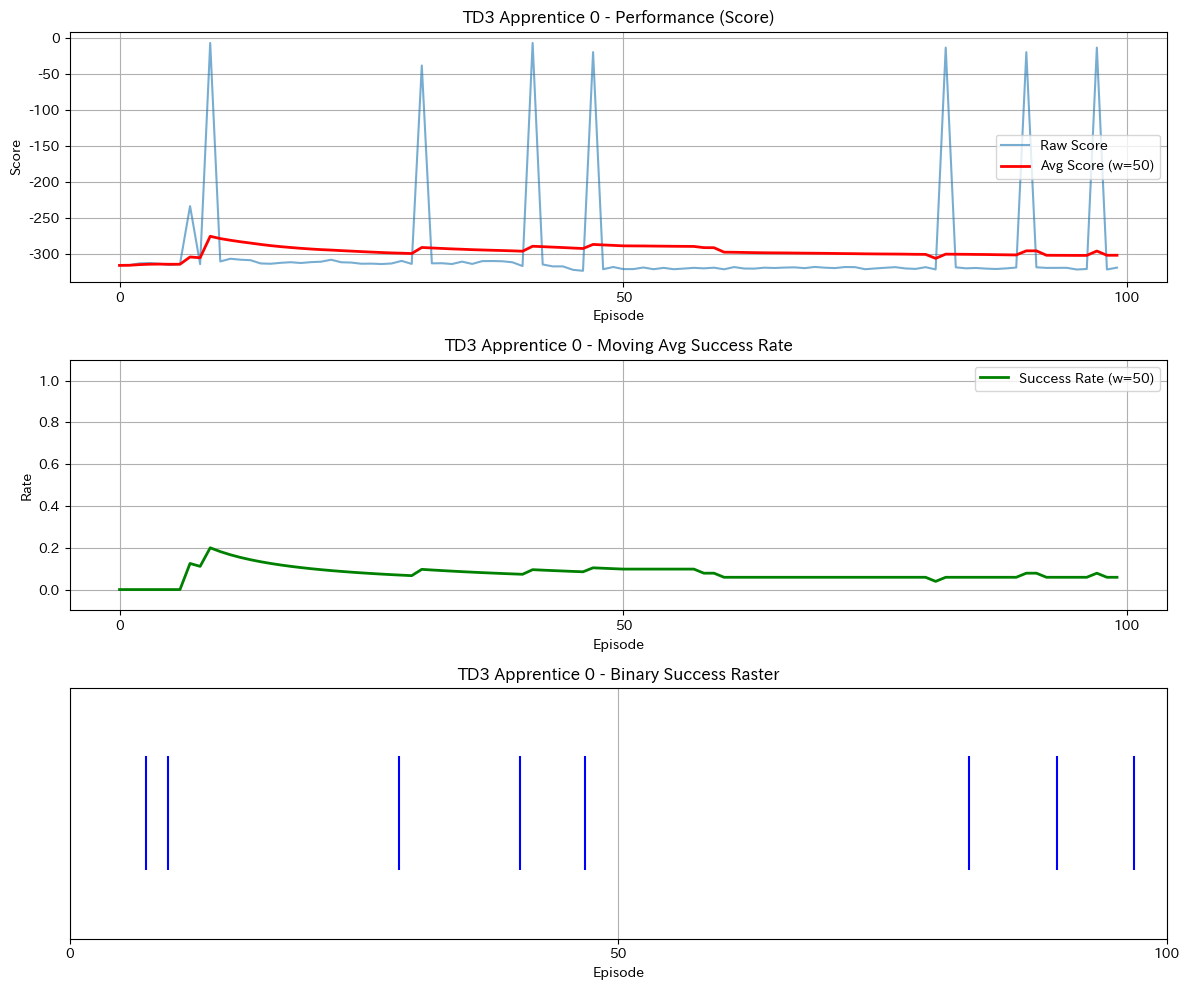


  TD3 Apprentice 1 Training

Margin[1]: 1.335384


Training..:  10%|█         | 51/500 [00:15<02:18,  3.24it/s]

Episode: 50 	 Steps: 50 	 Score: -17.7 	 Recent Avg Score: -15.6 	 Success: 5/50 (10.0%)


Training..:  20%|██        | 102/500 [00:30<01:22,  4.83it/s]

Episode: 100 	 Steps: 50 	 Score: -17.2 	 Recent Avg Score: -16.9 	 Success: 3/50 (6.0%)


...

Training..:  81%|████████  | 403/500 [01:14<00:09, 10.36it/s]

Episode: 400 	 Steps: 4 	 Score: -1.3 	 Recent Avg Score: -1.4 	 Success: 49/50 (98.0%)


Training..:  90%|█████████ | 451/500 [01:19<00:05,  9.34it/s]

Episode: 450 	 Steps: 4 	 Score: -1.4 	 Recent Avg Score: -1.1 	 Success: 50/50 (100.0%)


Training..: 100%|██████████| 500/500 [01:24<00:00,  5.94it/s]


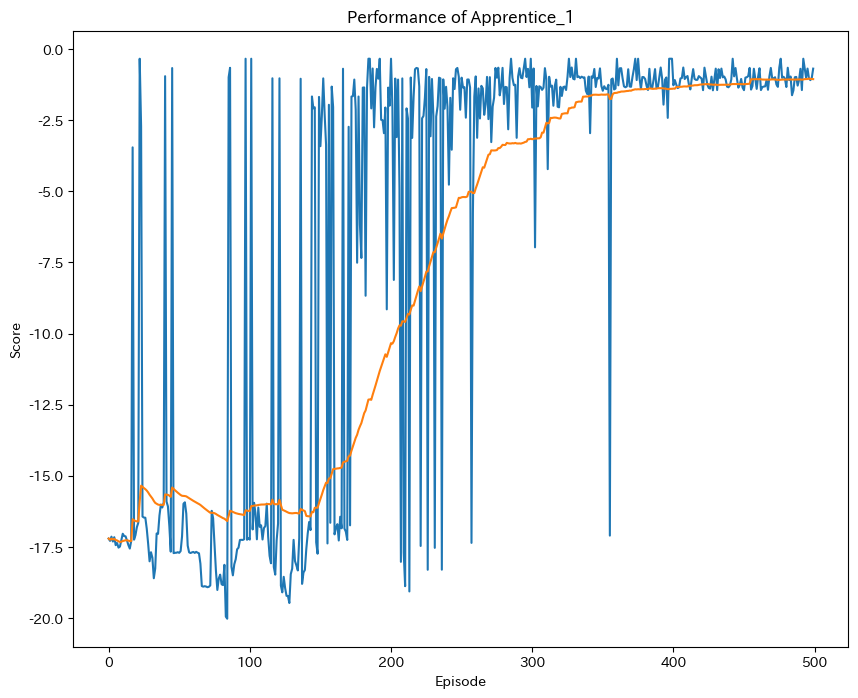

Computing features and rewards: 100%|██████████| 1000/1000 [00:28<00:00, 35.19it/s]



Feature expectation:  tensor([[ 0.0235,  0.0069,  0.1658, -0.2168,  0.0732, -0.2755,  0.0235,  0.0069,
          0.1658, -0.0010,  0.0030,  0.1465]], device='cuda:0')

Mean reward:  -2.34

--- TD3 Apprentice 1 Stats (per 50 episodes) ---
Chunk  Range           Success    Fail       Rate      
------------------------------------------------------------
0      0-49            5.0        45.0        10.00%
1      50-99           3.0        47.0         6.00%
2      100-149         8.0        42.0        16.00%
3      150-199         38.0       12.0        76.00%
4      200-249         42.0       8.0         84.00%
5      250-299         49.0       1.0         98.00%
6      300-349         50.0       0.0        100.00%
7      350-399         49.0       1.0         98.00%
8      400-449         50.0       0.0        100.00%
9      450-499         50.0       0.0        100.00%



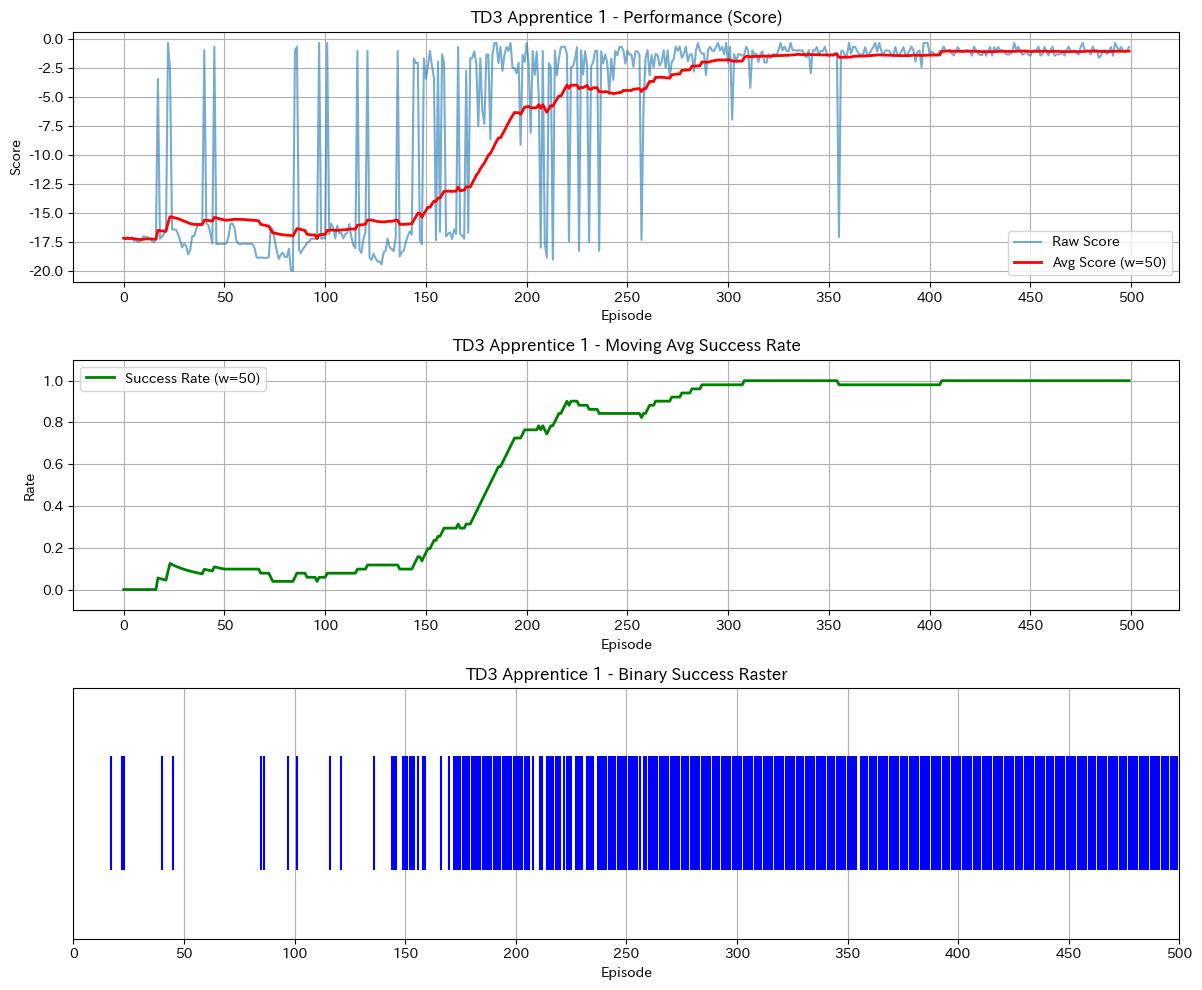


  TD3 Apprentice 2 Training

Margin[2]: 0.076344


Training..:  10%|█         | 51/500 [00:15<02:26,  3.06it/s]

Episode: 50 	 Steps: 50 	 Score: -0.6 	 Recent Avg Score: -0.6 	 Success: 2/50 (4.0%)


Training..:  20%|██        | 101/500 [00:28<01:19,  5.01it/s]

Episode: 100 	 Steps: 1 	 Score: -0.0 	 Recent Avg Score: -0.6 	 Success: 6/50 (12.0%)


...

Training..:  80%|████████  | 401/500 [01:11<00:10,  9.27it/s]

Episode: 400 	 Steps: 3 	 Score: -0.0 	 Recent Avg Score: -0.0 	 Success: 50/50 (100.0%)


Training..:  90%|█████████ | 451/500 [01:17<00:05,  9.01it/s]

Episode: 450 	 Steps: 3 	 Score: -0.0 	 Recent Avg Score: -0.1 	 Success: 49/50 (98.0%)


Training..: 100%|██████████| 500/500 [01:22<00:00,  6.08it/s]


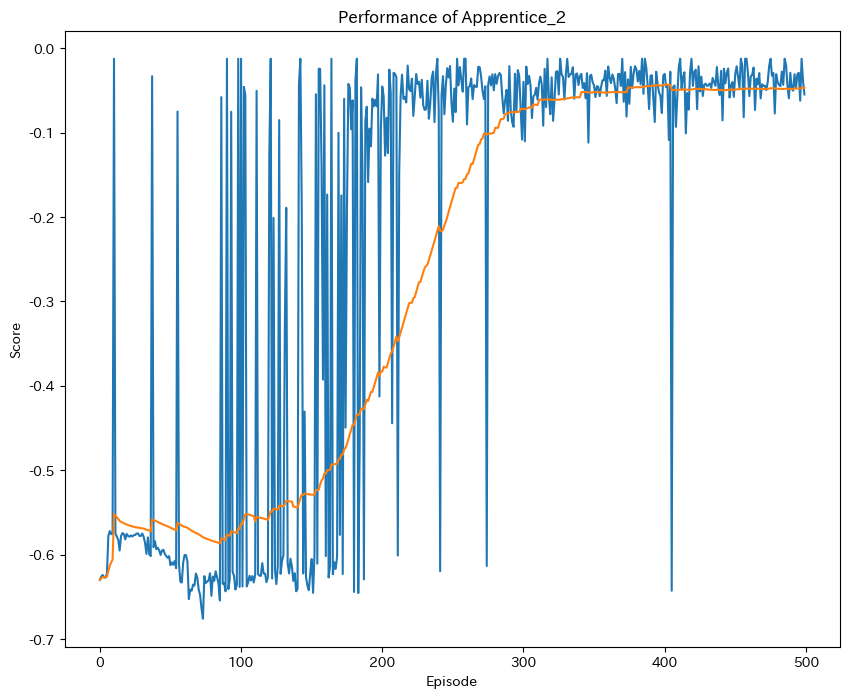

Computing features and rewards: 100%|██████████| 1000/1000 [00:27<00:00, 35.81it/s]



Feature expectation:  tensor([[ 0.0166, -0.0033,  0.1810, -0.2054,  0.0149, -0.1832,  0.0166, -0.0033,
          0.1810, -0.0044,  0.0055,  0.1524]], device='cuda:0')

Mean reward:  -2.093

--- TD3 Apprentice 2 Stats (per 50 episodes) ---
Chunk  Range           Success    Fail       Rate      
------------------------------------------------------------
0      0-49            2.0        48.0         4.00%
1      50-99           5.0        45.0        10.00%
2      100-149         14.0       36.0        28.00%
3      150-199         35.0       15.0        70.00%
4      200-249         48.0       2.0         96.00%
5      250-299         49.0       1.0         98.00%
6      300-349         50.0       0.0        100.00%
7      350-399         50.0       0.0        100.00%
8      400-449         49.0       1.0         98.00%
9      450-499         50.0       0.0        100.00%



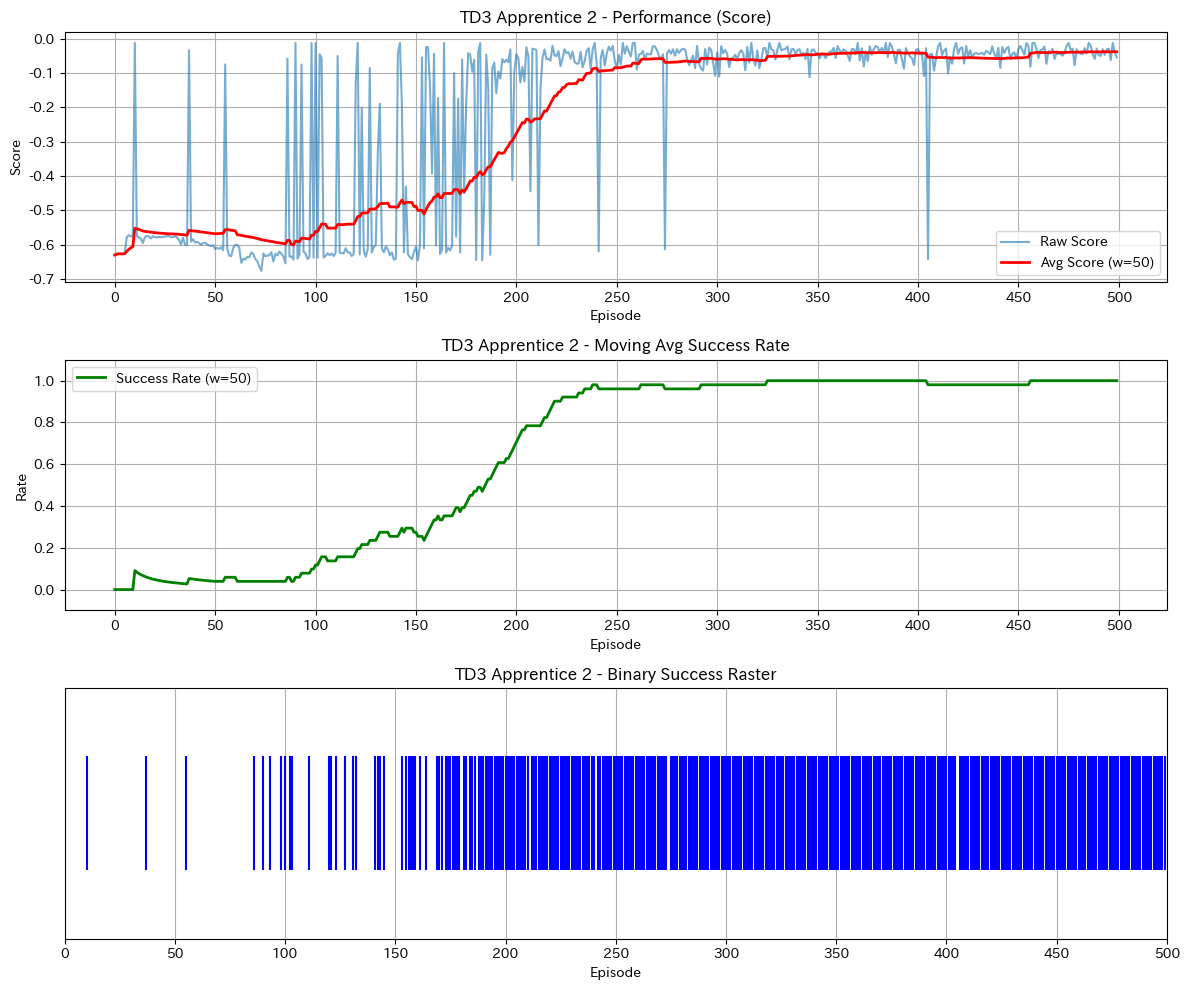


  TD3 Apprentice 3 Training

Margin[3]: 0.056761


Training..:  10%|█         | 51/500 [00:14<02:14,  3.35it/s]

Episode: 50 	 Steps: 50 	 Score: -1.2 	 Recent Avg Score: -1.1 	 Success: 7/50 (14.0%)


Training..:  20%|██        | 101/500 [00:28<02:14,  2.96it/s]

Episode: 100 	 Steps: 50 	 Score: -1.2 	 Recent Avg Score: -1.1 	 Success: 5/50 (10.0%)


...

Training..:  80%|████████  | 401/500 [01:51<00:25,  3.89it/s]

Episode: 400 	 Steps: 50 	 Score: -1.2 	 Recent Avg Score: -1.0 	 Success: 9/50 (18.0%)


Training..:  90%|█████████ | 452/500 [02:04<00:08,  5.37it/s]

Episode: 450 	 Steps: 1 	 Score: -0.0 	 Recent Avg Score: -0.9 	 Success: 11/50 (22.0%)


Training..: 100%|██████████| 500/500 [02:16<00:00,  3.66it/s]


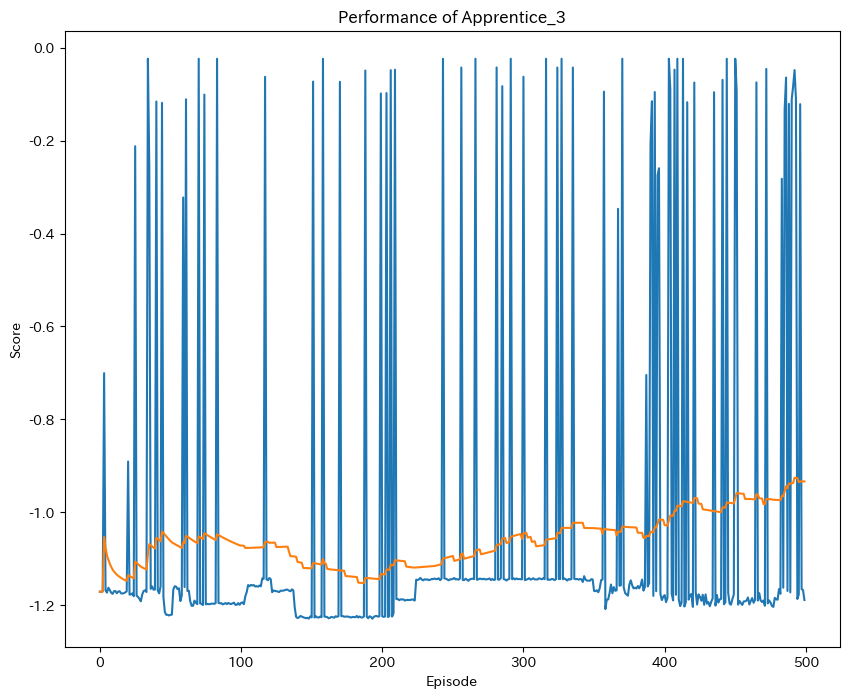

Computing features and rewards: 100%|██████████| 1000/1000 [01:30<00:00, 10.99it/s]



Feature expectation:  tensor([[-0.0326,  0.0102,  0.0440, -0.1584,  0.0673, -0.2354, -0.0326,  0.0102,
          0.0440, -0.0027,  0.0038,  0.1519]], device='cuda:0')

Mean reward:  -38.579

--- TD3 Apprentice 3 Stats (per 50 episodes) ---
Chunk  Range           Success    Fail       Rate      
------------------------------------------------------------
0      0-49            7.0        43.0        14.00%
1      50-99           5.0        45.0        10.00%
2      100-149         1.0        49.0         2.00%
3      150-199         5.0        45.0        10.00%
4      200-249         4.0        46.0         8.00%
5      250-299         5.0        45.0        10.00%
6      300-349         5.0        45.0        10.00%
7      350-399         9.0        41.0        18.00%
8      400-449         10.0       40.0        20.00%
9      450-499         13.0       37.0        26.00%



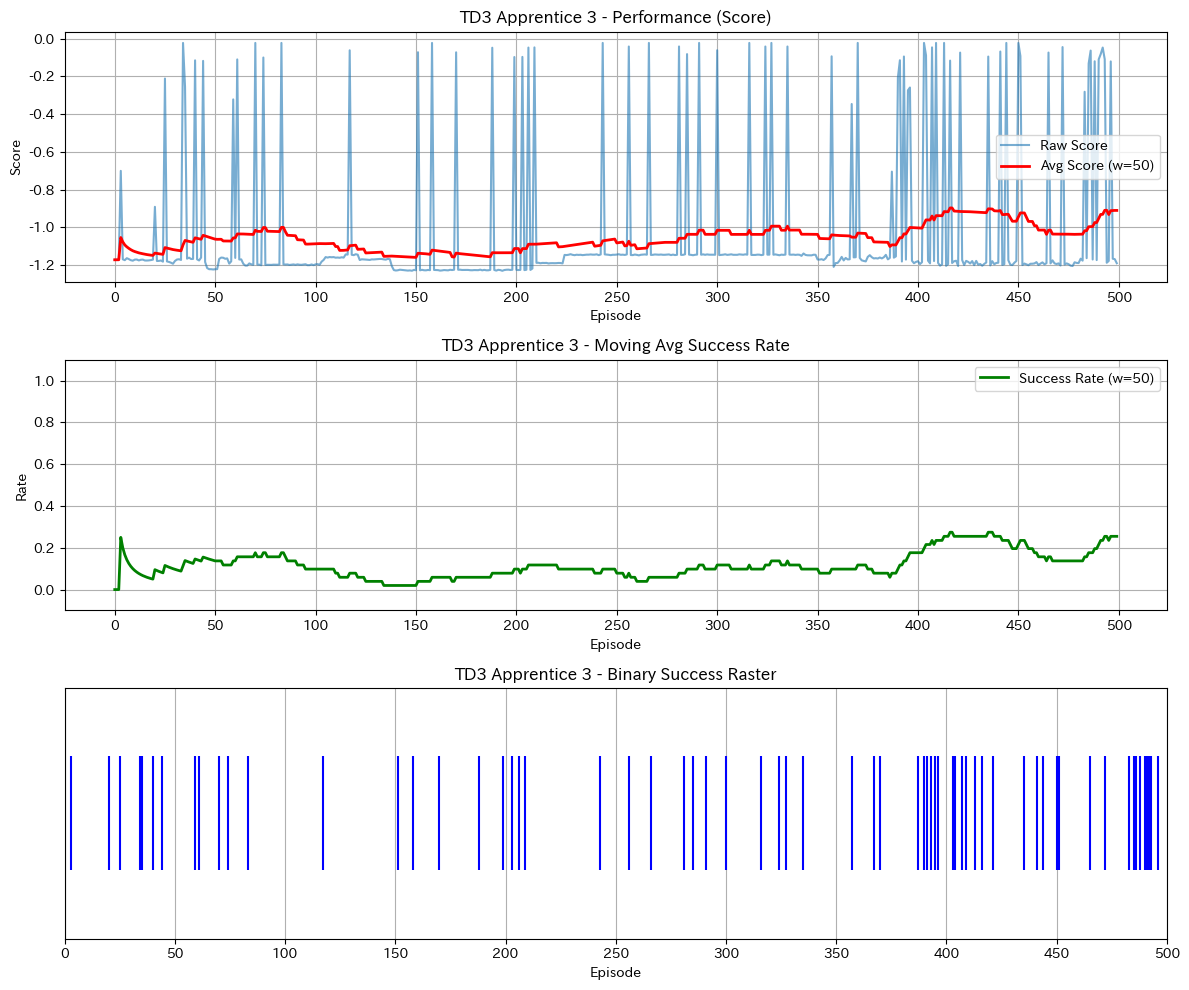

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/TD3/TD3_Apprentice_Comparison_Performance.png


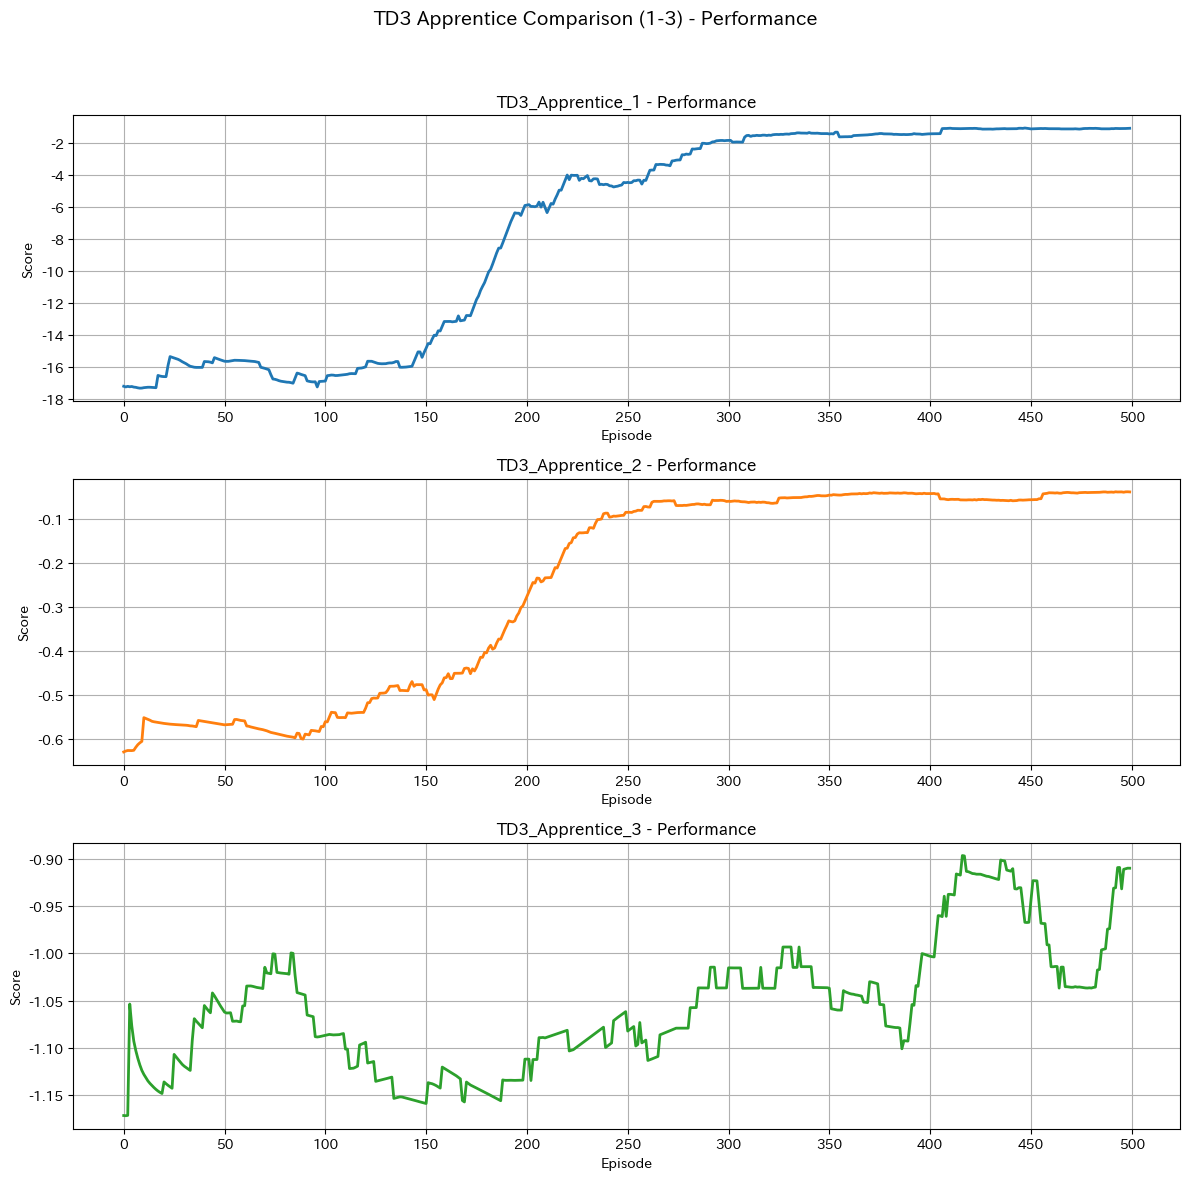

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/TD3/TD3_Apprentice_Comparison_Success.png


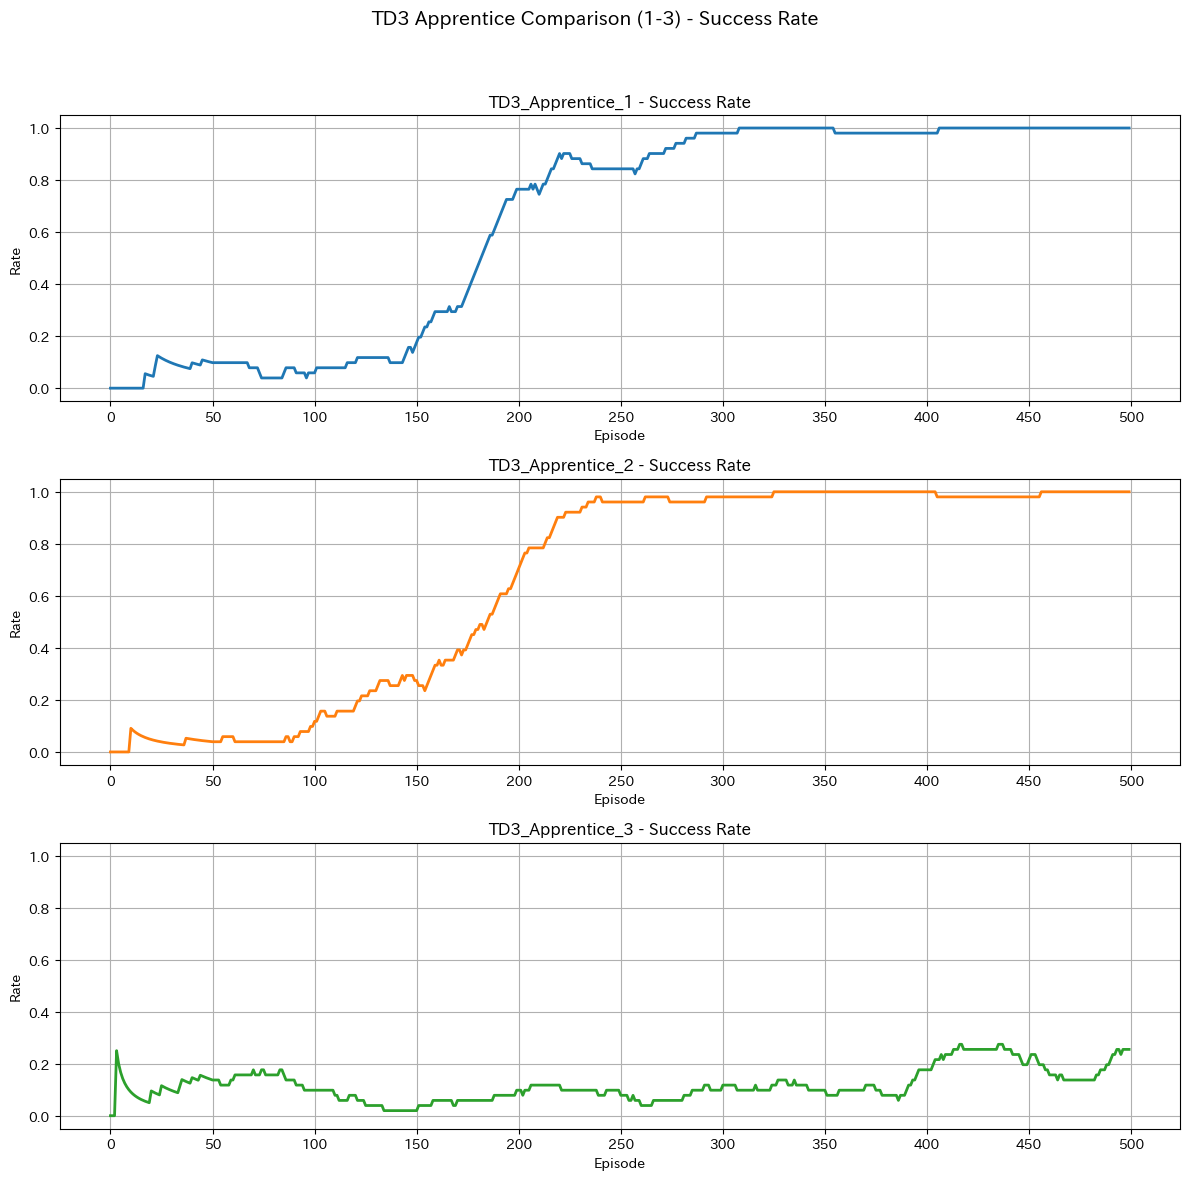

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/TD3/TD3_Apprentice_Comparison_Raster.png


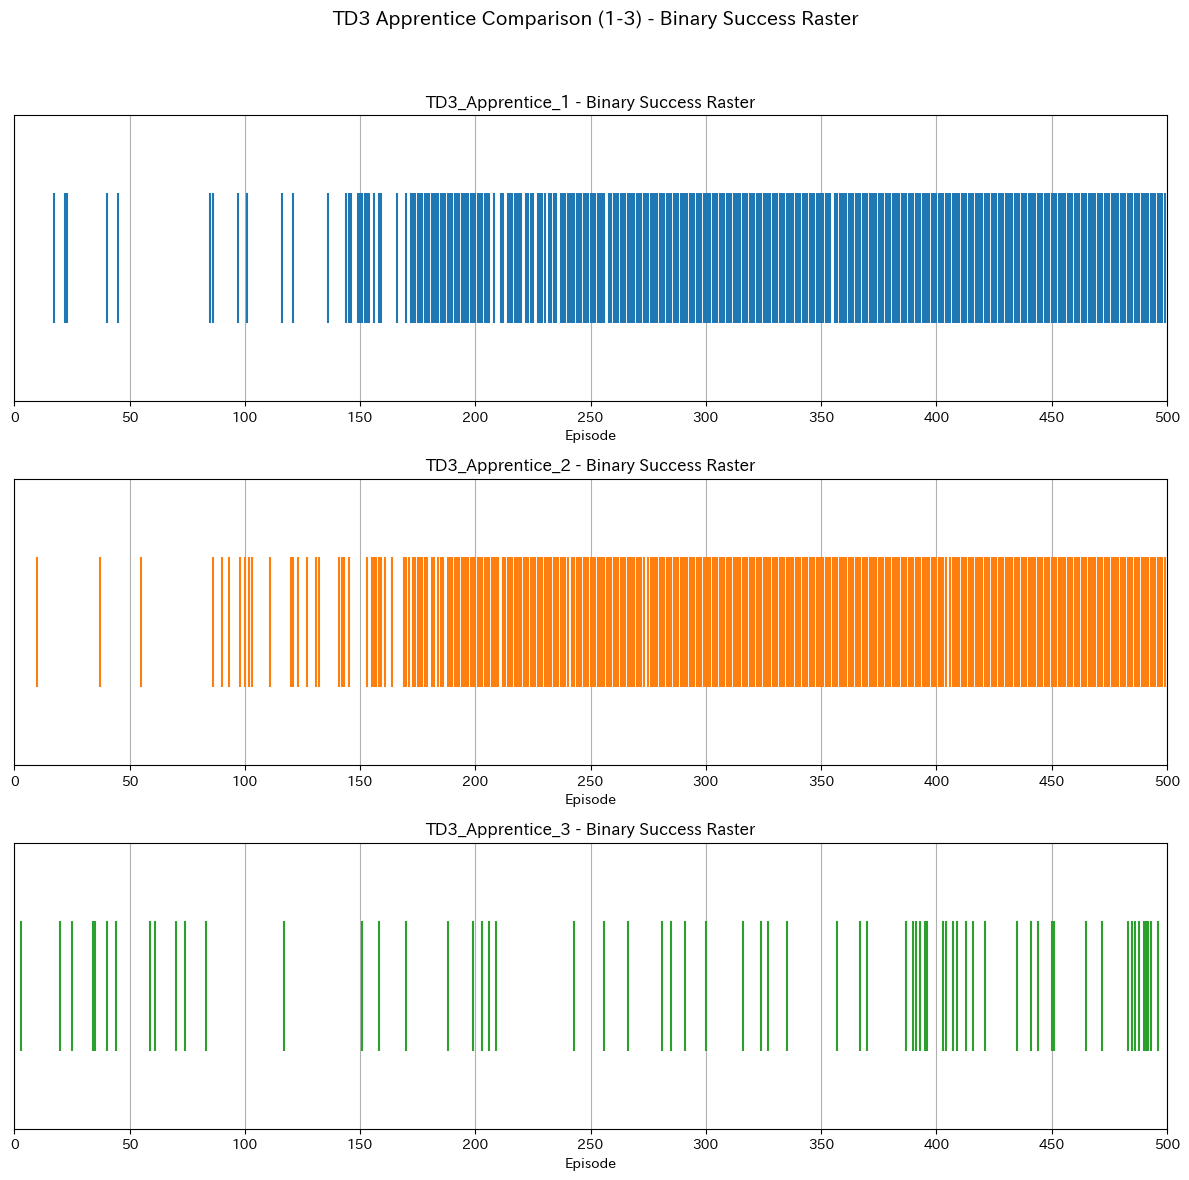

numActiveThreads = 0
stopping threads
Thread with taskId 0 exiting
Thread TERMINATED
destroy semaphore
semaphore destroyed
destroy main semaphore
main semaphore destroyed
finished
numActiveThreads = 0
btShutDownExampleBrowser stopping threads
Thread with taskId 0 exiting
Thread TERMINATED
destroy semaphore
semaphore destroyed
destroy main semaphore
main semaphore destroyed


In [4]:
# Train TD3 Apprentices 0-3 using projection method
td3_apprentice_train_data = td3_runner.train_apprentices(td3_expert)

## 4. TD3 Apprentice Evaluation


### Apprentice Evaluation Algorithm

Each trained Apprentice agent (0 to 3) is evaluated separately over $N=500$ episodes.

**1. Stochastic Policy:**
Evaluations use the same stochastic exploration policy (Gaussian noise) as the Expert to ensure a fair comparison:
$$ a_t = \text{clip}(\pi_{\theta_{\text{app}}}(s_t) + \epsilon, a_{\text{min}}, a_{\text{max}}), \quad \epsilon \sim \mathcal{N}(0, 0.1) $$

**2. Metrics:**
We use same metrics as the Expert evaluation:
- **Mean Return:** Average cumulative reward (from the *original environment*, not the synthetic IRL reward).
  $$ \bar{G} = \frac{1}{N} \sum_{i=1}^N G_i $$

- **Success Rate:** Percentage of successful episodes.
  $$ S = \frac{1}{N} \sum_{i=1}^N \mathbb{I}(\text{success}^{(i)}) \times 100 $$

**Symbol Definitions:**
- $N$: Number of evaluation episodes per apprentice (500)
- $\pi_{\theta_{\text{app}}}$: Apprentice policy parameterised by $\theta_{\text{app}}$
- $\epsilon$: Exploration noise $\mathcal{N}(0, 0.1)$
- $G_i$: Cumulative return of episode $i$
- $\mathbb{I}(\cdot)$: Indicator function



In [5]:
# Evaluate TD3 Apprentices
td3_apprentice_eval_data = td3_runner.evaluate_apprentices()

argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color_green=0.21176470816135406
argv[2]=--background_color_blue=0.1764705926179886
startThreads creating 1 threads.
starting thread 0

--- Evaluating TD3 Apprentice 0 ---
started thread 0 
argc=5
argv[0] = --unused
argv[1] = --background_color_red=0.8745098114013672
argv[2] = --background_color_green=0.21176470816135406
argv[3] = --background_color_blue=0.1764705926179886
argv[4] = --start_demo_name=Physics Server
ExampleBrowserThreadFunc started
X11 functions dynamically loaded using dlopen/dlsym OK!
X11 functions dynamically loaded using dlopen/dlsym OK!
Creating context
Created GL 3.3 context
Direct GLX rendering context obtained
Making context current
GL_VENDOR=Mesa
GL_RENDERER=llvmpipe (LLVM 20.1.2, 256 bits)
GL_VERSION=4.5 (Core Profile) Mesa 25.0.7-0ubuntu0.24.04.2
GL_SHADING_LANGUAGE_VERSION=4.50
pthread_getconcurrency()=0
Version = 4.5 (Core Profile) Mesa 25.0.7-0ubuntu0.24.04.2
Vendor = Mesa
Renderer = llv

Evaluating:   0%|          | 0/500 [00:00<?, ?it/s]

ven = Mesa


Evaluating: 100%|██████████| 500/500 [00:53<00:00,  9.30it/s]


TD3 Apprentice 0 Evaluation: Mean Return = -47.456, Success: 26/500 (5.2%)

--- TD3 Apprentice 0 (Eval) Stats (per 50 episodes) ---
Chunk  Range           Success    Fail       Rate      
------------------------------------------------------------
0      0-49            4          46           8.00%
1      50-99           3          47           6.00%
2      100-149         2          48           4.00%
3      150-199         1          49           2.00%
4      200-249         1          49           2.00%
5      250-299         3          47           6.00%
6      300-349         2          48           4.00%
7      350-399         2          48           4.00%
8      400-449         5          45          10.00%
9      450-499         3          47           6.00%


--- Evaluating TD3 Apprentice 1 ---
Evaluating agent for 500 episodes...


...

TD3 Apprentice 1 Evaluation: Mean Return = -2.184, Success: 500/500 (100.0%)

--- TD3 Apprentice 1 (Eval) Stats (per 50 episodes) ---
Chunk  Range           Success    Fail       Rate      
------------------------------------------------------------
0      0-49            50         0          100.00%
1      50-99           50         0          100.00%
2      100-149         50         0          100.00%
3      150-199         50         0          100.00%
4      200-249         50         0          100.00%
5      250-299         50         0          100.00%
6      300-349         50         0          100.00%
7      350-399         50         0          100.00%
8      400-449         50         0          100.00%
9      450-499         50         0          100.00%


--- Evaluating TD3 Apprentice 2 ---
Evaluating agent for 500 episodes...


Evaluating: 100%|██████████| 500/500 [00:14<00:00, 35.43it/s]


TD3 Apprentice 2 Evaluation: Mean Return = -2.142, Success: 500/500 (100.0%)

--- TD3 Apprentice 2 (Eval) Stats (per 50 episodes) ---
Chunk  Range           Success    Fail       Rate      
------------------------------------------------------------
0      0-49            50         0          100.00%
1      50-99           50         0          100.00%
2      100-149         50         0          100.00%
3      150-199         50         0          100.00%
4      200-249         50         0          100.00%
5      250-299         50         0          100.00%
6      300-349         50         0          100.00%
7      350-399         50         0          100.00%
8      400-449         50         0          100.00%
9      450-499         50         0          100.00%


--- Evaluating TD3 Apprentice 3 ---
Evaluating agent for 500 episodes...


Evaluating: 100%|██████████| 500/500 [00:44<00:00, 11.24it/s]

TD3 Apprentice 3 Evaluation: Mean Return = -38.602, Success: 138/500 (27.6%)

--- TD3 Apprentice 3 (Eval) Stats (per 50 episodes) ---
Chunk  Range           Success    Fail       Rate      
------------------------------------------------------------
0      0-49            15         35          30.00%
1      50-99           14         36          28.00%
2      100-149         15         35          30.00%
3      150-199         14         36          28.00%
4      200-249         16         34          32.00%
5      250-299         12         38          24.00%
6      300-349         14         36          28.00%
7      350-399         15         35          30.00%
8      400-449         14         36          28.00%
9      450-499         9          41          18.00%

numActiveThreads = 0
stopping threads
Thread with taskId 0 exiting
Thread TERMINATED
destroy semaphore
semaphore destroyed
destroy main semaphore
main semaphore destroyed
finished
numActiveThreads = 0
btShutDownExample

## 5. TD3 Comparative Plots


### TD3 Comparative Analysis

This section compares the performance of the **TD3 Expert** against the **TD3 Apprentices (1-3)**.
The goal is to verify if the apprentices successfully recover the expert's behavior using the synthesized IRL reward.

**1. Metrics Visualization:**
- **Smoothed Score:** Moving average of episode returns ($w=50$).
  $$ \bar{G}_t = \frac{1}{w} \sum_{i=0}^{w-1} G_{t-i} $$
- **Success Rate:** Moving average of binary success indicators.

**2. Comparative Focus:**
- **Stability:** Are apprentice learning curves stable compared to the expert?
- **Convergence:** Do apprentices reach similar final performance levels?

**Symbol Definitions:**
- $\bar{G}_t$: Smoothed return at episode $t$
- $w$: Window size (50)



Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/TD3/TD3_Learning_Comparison_Performance.png


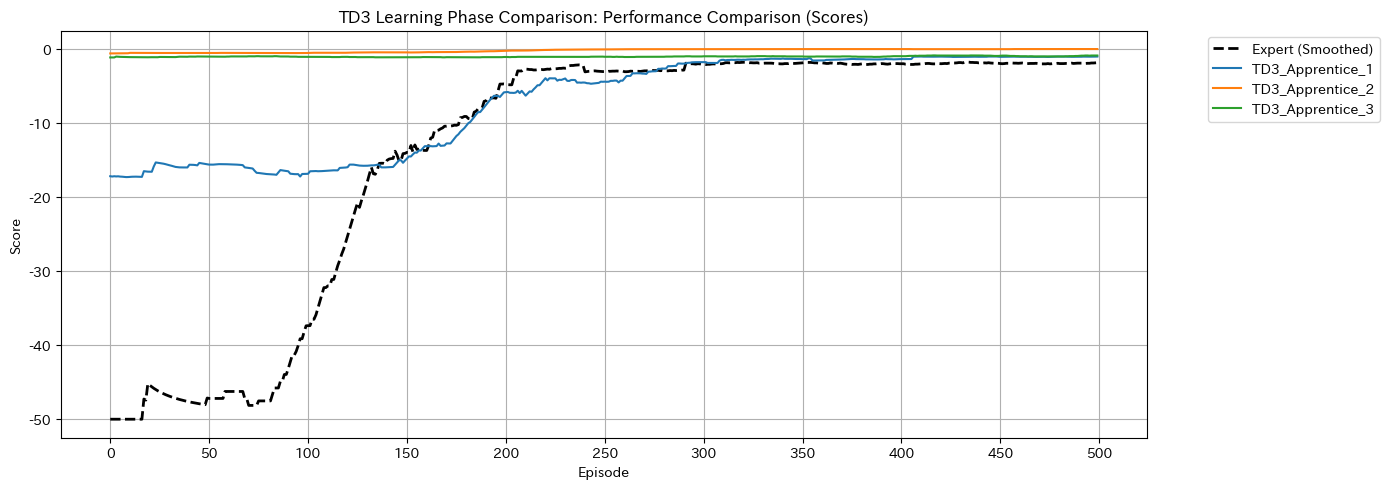

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/TD3/TD3_Learning_Comparison_SuccessRate.png


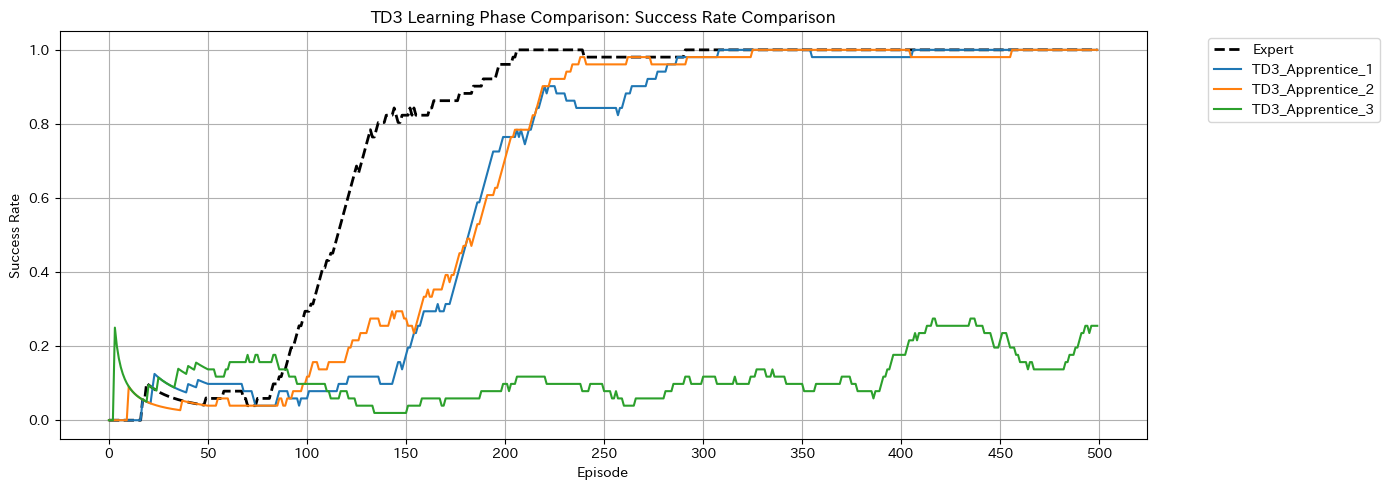

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/TD3/TD3_Learning_Comparison_Raster.png


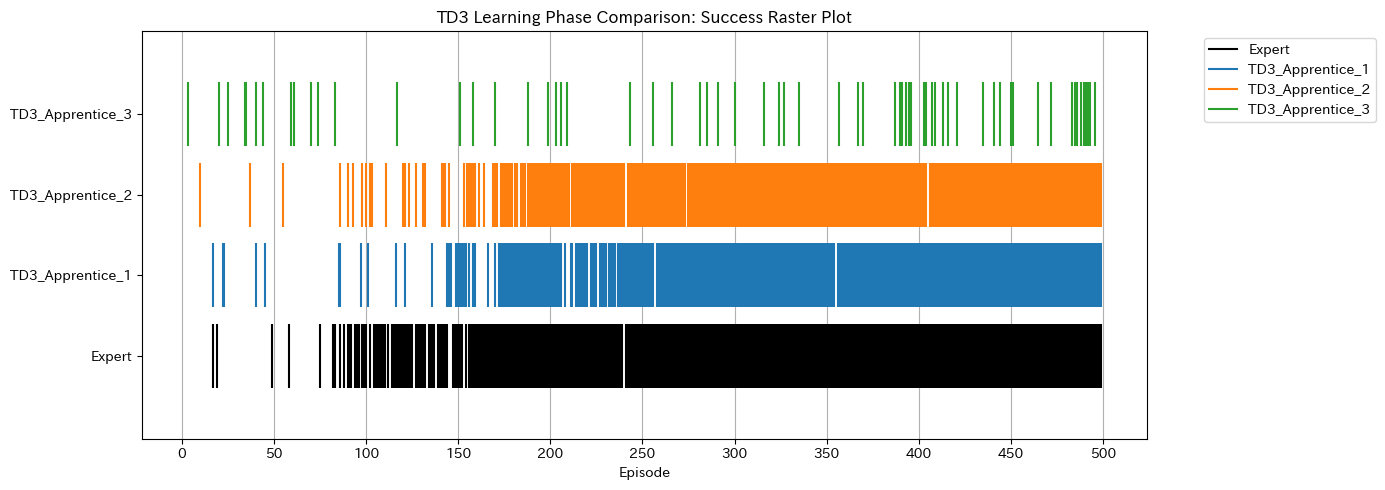

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/TD3/TD3_Apprentice_Comparison_Performance.png


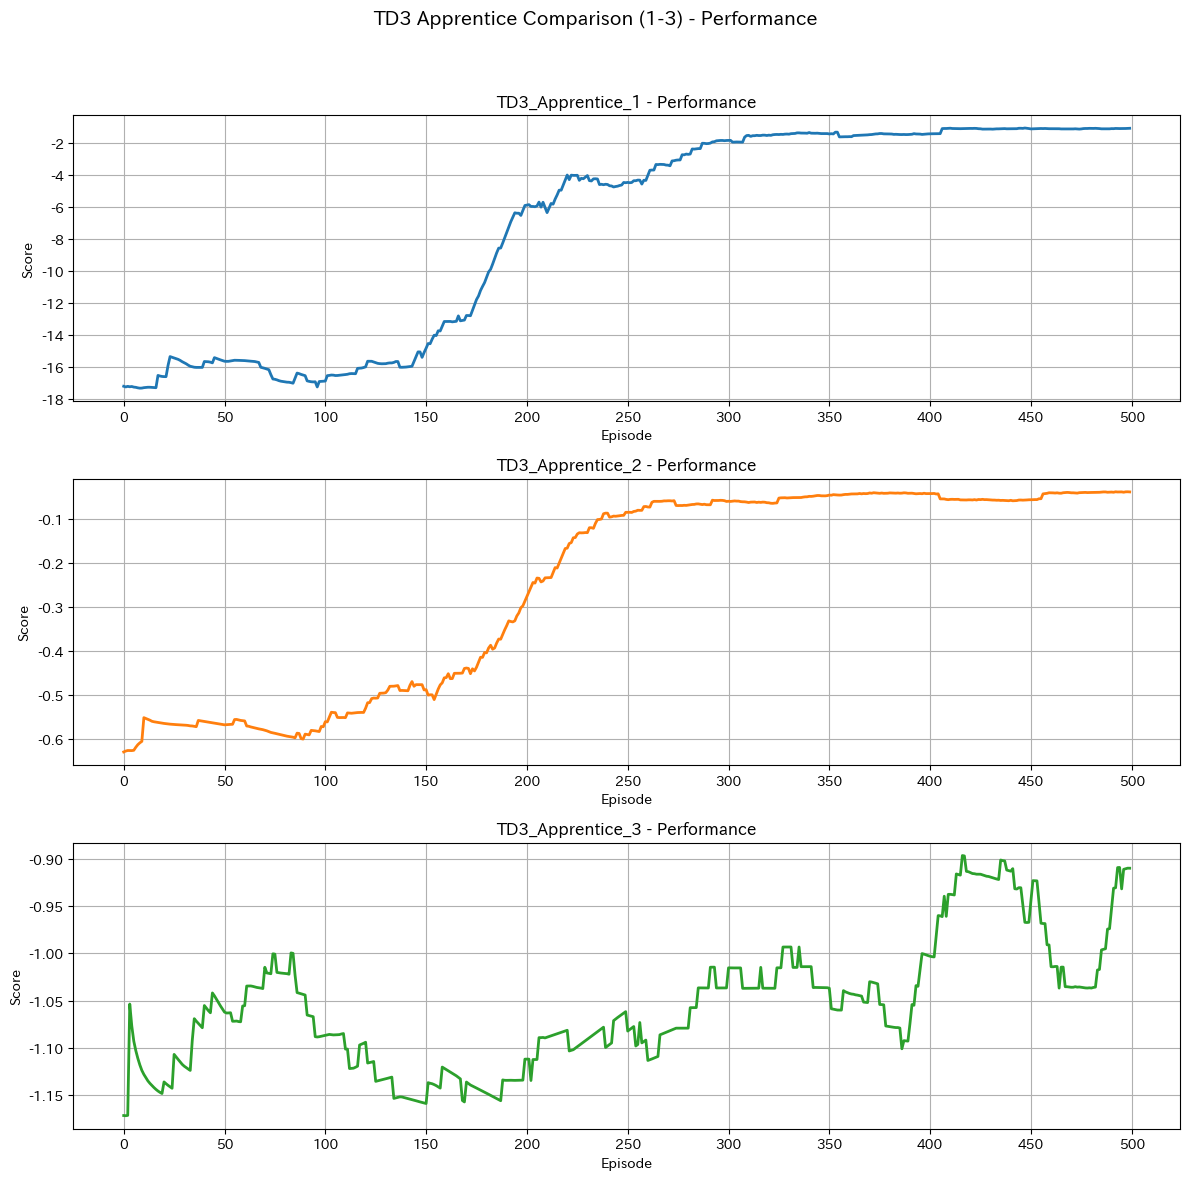

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/TD3/TD3_Apprentice_Comparison_Success.png


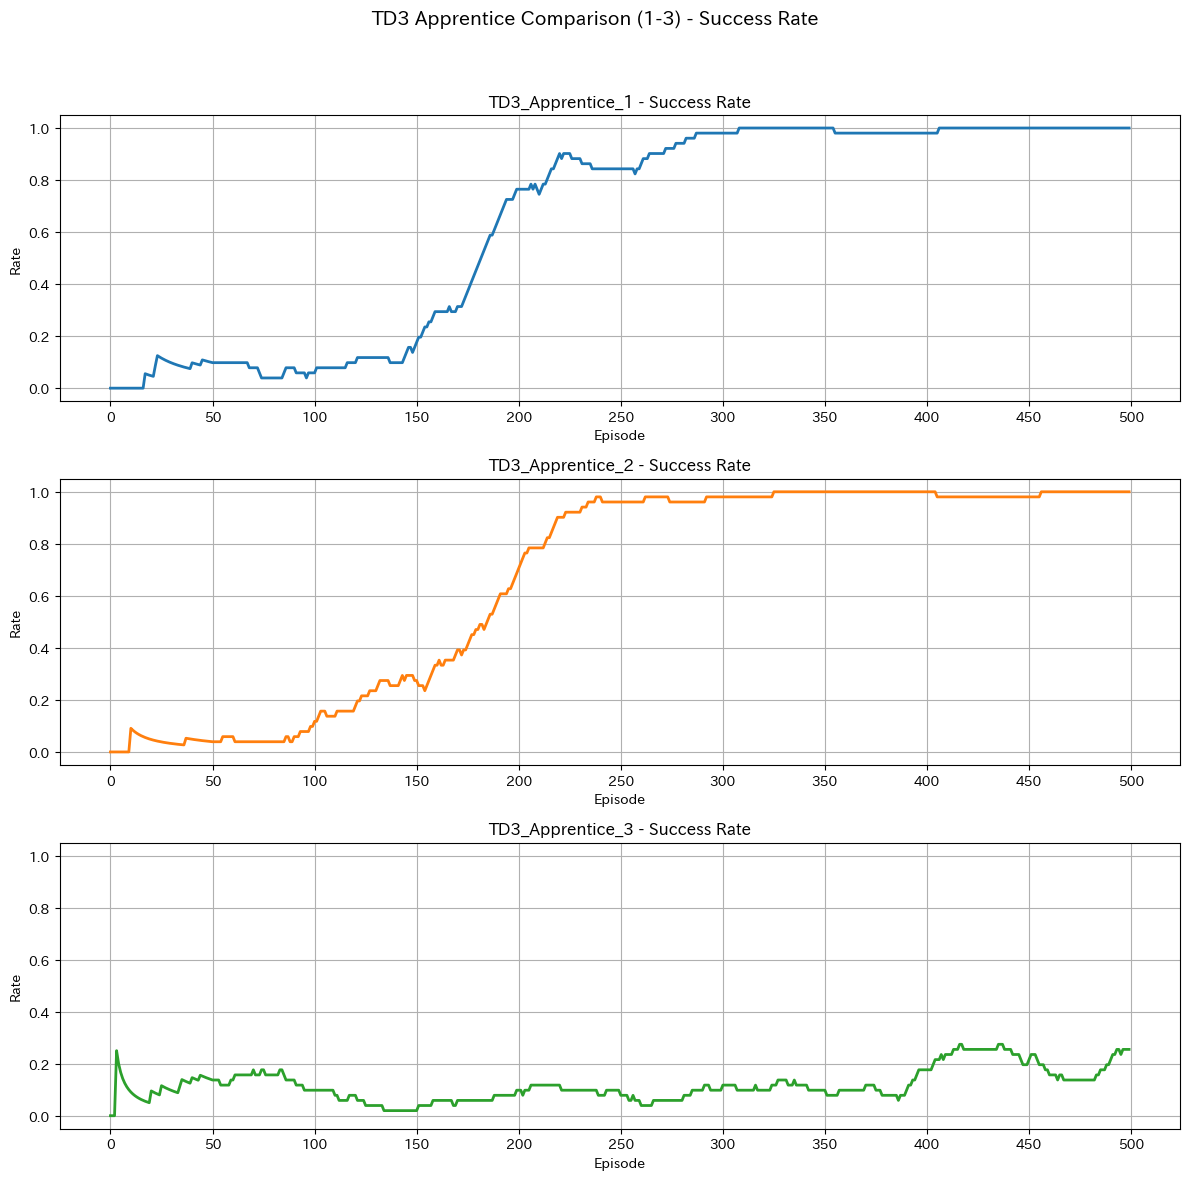

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/TD3/TD3_Apprentice_Comparison_Raster.png


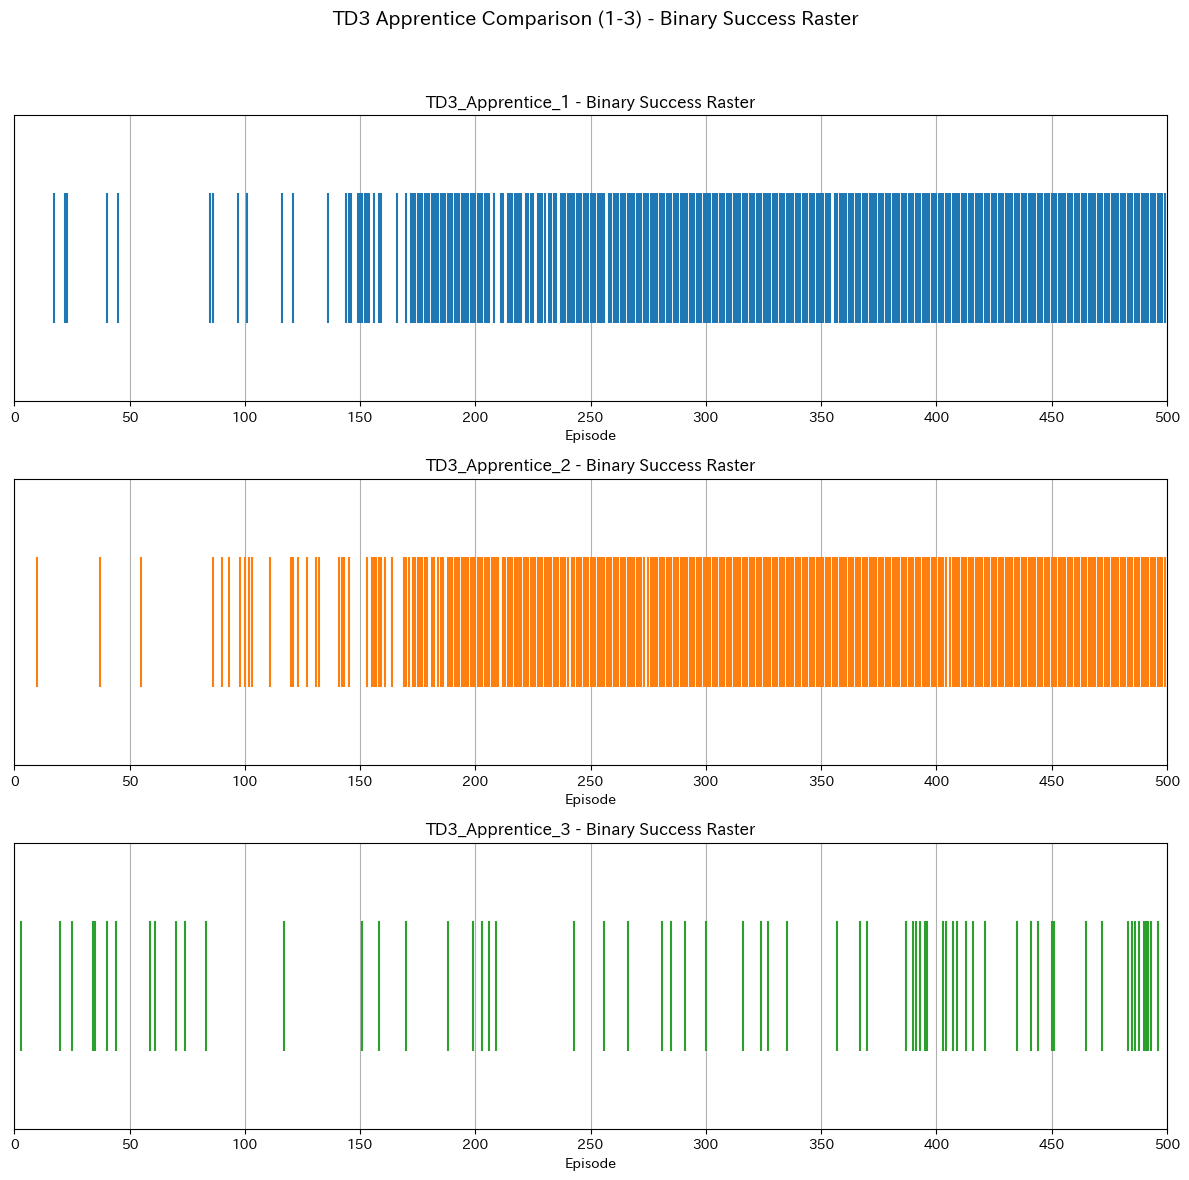

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/TD3/TD3_Evaluation_Comparison_Performance.png


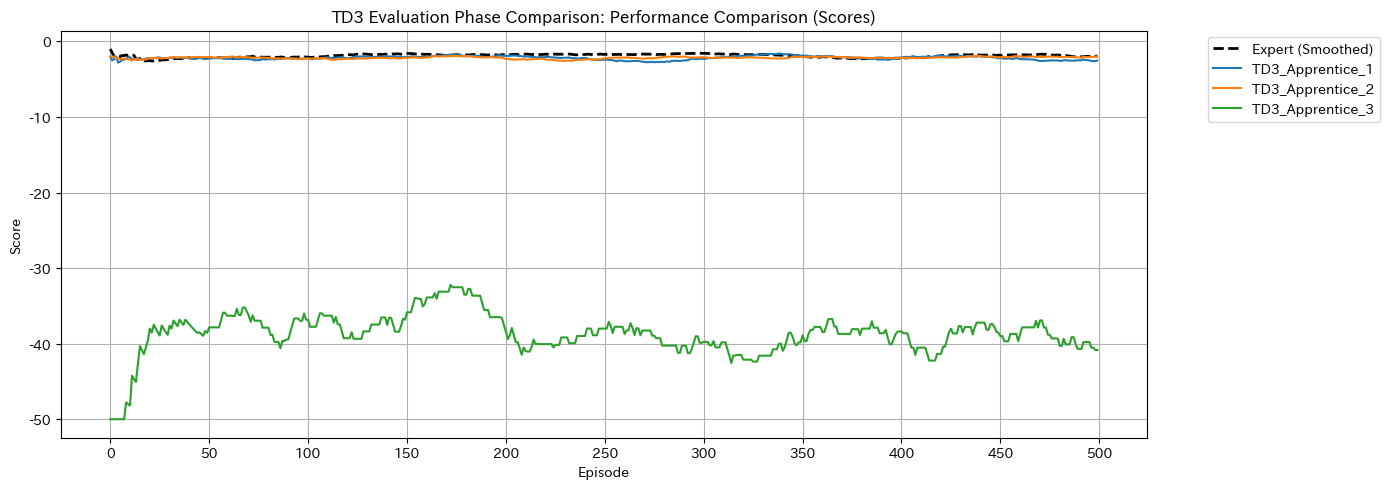

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/TD3/TD3_Evaluation_Comparison_SuccessRate.png


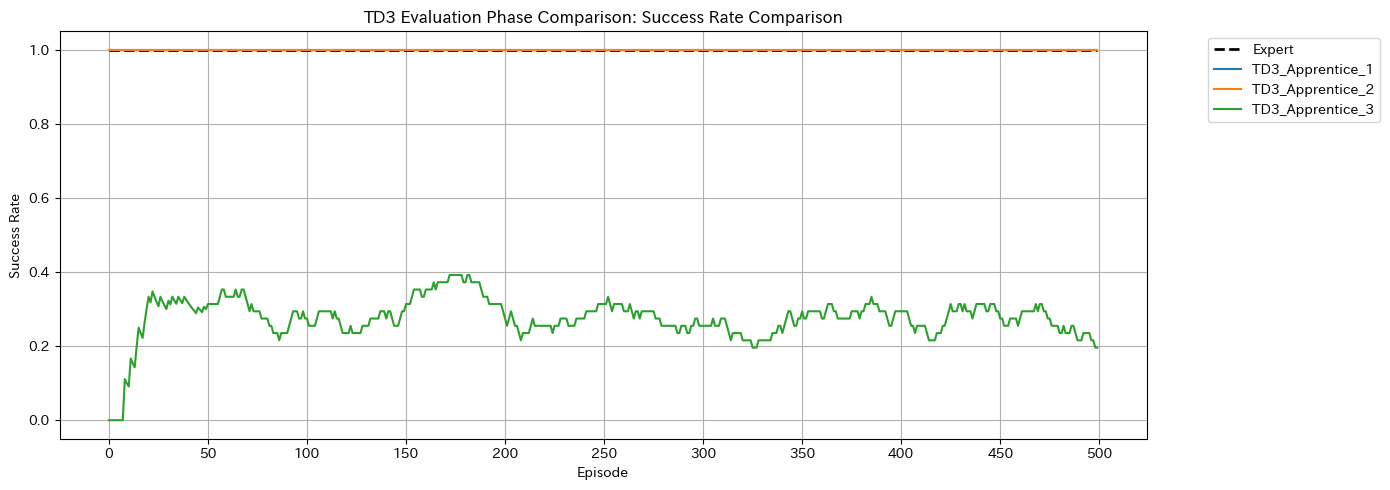

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/TD3/TD3_Evaluation_Comparison_Raster.png


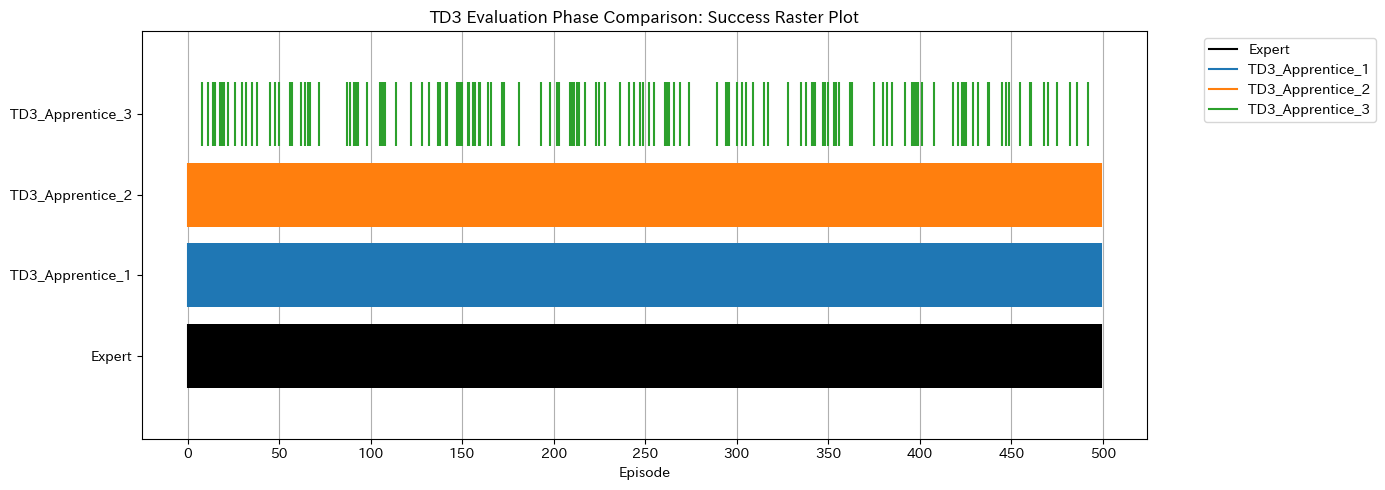

In [6]:
import compare_utils
# Plot TD3 comparisons
# Filter out Apprentice 0
filtered_td3_train_data = compare_utils.filter_apprentice_data(td3_apprentice_train_data, "TD3_Apprentice_0")
filtered_td3_eval_data = compare_utils.filter_apprentice_data(td3_apprentice_eval_data, "TD3_Apprentice_0")

td3_runner.plot_all_comparisons(
    td3_expert_train_data,
    td3_expert_eval_data,
    filtered_td3_train_data,
    filtered_td3_eval_data
)

## 6. GAIL Apprentice Training (1-3)

### Generative Adversarial Imitation Learning (GAIL)

* **Imitation Learning (IL)**: The goal is to learn a policy that mimics the behavior of an expert, given a set of expert demonstrations.

* **GAIL Concept**: GAIL formulates imitation learning as a min-max game similar to Generative Adversarial Networks (GANs).
  * **Generator (Apprentice Policy, $\pi_\theta$)**: Tries to generate state-action pairs that resemble the expert's behavior to 'fool' the discriminator.
  * **Discriminator ($D_\psi$)**: Tries to distinguish between state-action pairs generated by the expert and those generated by the apprentice.

**Key Equations:**

1. **Discriminator Objective (Minimize Cross-Entropy Loss):**
   The discriminator is trained to classify expert samples as 1 and apprentice samples as 0.
   $$ L_D(\psi) = -\mathbb{E}_{(s,a)_E} [\log D_\psi(s, a)] - \mathbb{E}_{(s,a)_\pi} [\log(1 - D_\psi(s, a))] $$

2. **Synthetic Reward Signal:**
   The apprentice receives a high reward when the discriminator is 'confused' (i.e., when $D_\psi(s,a)$ is close to 1).
   $$ r_{gail}(s, a) = -\log(1 - D_\psi(s, a)) $$

3. **Apprentice Objective:**
   The apprentice policy $\pi_\theta$ is optimized using TRPO/PPO (or TD3 in this implementation) to maximize the expected synthetic reward.
   $$ \max_\theta \mathbb{E}_{\pi_\theta}[r_{gail}(s, a)] $$


### Generative Adversarial Imitation Learning (GAIL)

GAIL is an imitation learning algorithm that leverages Generative Adversarial Networks (GANs).
It uses a discriminator $D_\psi$ to distinguish between Expert state-action pairs and those generated by the Apprentice policy $\pi_\theta$.
The Apprentice learns to maximize a reward signal derived from the discriminator's confusion.

**Algorithm Steps:**

1. **Discriminator Training:**
   - Sample expert batch $(s, a)_E$ and apprentice batch $(s, a)_\pi$ of size $N$.
   - Update Discriminator parameters $\psi$ to minimize cross-entropy loss:
     $$ L_D(\psi) = -\frac{1}{N} \sum [\log D_\psi(s_E, a_E) + \log(1 - D_\psi(s_\pi, a_\pi))] $$

2. **Reward Calculation:**
   - Compute synthetic reward for the Apprentice based on discriminator output:
     $$ r_{\text{gail}}(s, a) = \log(D_\psi(s, a)) $$

3. **Apprentice Policy Update (TD3):**
   - The Apprentice is trained using the **TD3 Algorithm** (see Section 1) with the synthetic reward $r_{\text{gail}}$.
   - The objective is to maximize the expected GAIL reward:
     $$ \max_\theta \mathbb{E}_{\pi_\theta}[r_{\text{gail}}(s, a)] $$

**Symbol Definitions:**
- $N$: Batch size for discriminator training (256)
- $\pi_\theta$: Apprentice Policy parameters $\theta$
- $D_\psi$: Discriminator network parameters $\psi$
- $(s,a)_E$: State-action pairs sampled from Expert trajectories
- $(s,a)_\pi$: State-action pairs sampled from current Policy trajectories
- $\mathbb{E}$: Mathematical expectation



argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color_green=0.21176470816135406
argv[2]=--background_color_blue=0.1764705926179886
startThreads creating 1 threads.
starting thread 0
started thread 0 
argc=5
argv[0] = --unused
argv[1] = --background_color_red=0.8745098114013672
argv[2] = --background_color_green=0.21176470816135406
argv[3] = --background_color_blue=0.1764705926179886
argv[4] = --start_demo_name=Physics Server
ExampleBrowserThreadFunc started
X11 functions dynamically loaded using dlopen/dlsym OK!
X11 functions dynamically loaded using dlopen/dlsym OK!
Creating context
Created GL 3.3 context
Direct GLX rendering context obtained
Making context current
GL_VENDOR=Mesa
GL_RENDERER=llvmpipe (LLVM 20.1.2, 256 bits)
GL_VERSION=4.5 (Core Profile) Mesa 25.0.7-0ubuntu0.24.04.2
GL_SHADING_LANGUAGE_VERSION=4.50
pthread_getconcurrency()=0
Version = 4.5 (Core Profile) Mesa 25.0.7-0ubuntu0.24.04.2
Vendor = Mesa
Renderer = llvmpipe (LLVM 20.1.2, 256 bits)
b3Print

学習中..:  10%|█         | 51/500 [00:16<02:09,  3.47it/s]

Episode: 50 	 Steps: 20 	 Score: -23.4 	 Avg Score: -33.3 	 Success: 4/50 (8.0%)


学習中..:  20%|██        | 102/500 [00:30<01:32,  4.32it/s]

Episode: 100 	 Steps: 50 	 Score: -35.4 	 Avg Score: -29.2 	 Success: 11/50 (22.0%)


...

学習中..:  80%|████████  | 402/500 [01:25<00:11,  8.75it/s]

Episode: 400 	 Steps: 1 	 Score: -0.2 	 Avg Score: -5.1 	 Success: 50/50 (100.0%)


学習中..:  90%|█████████ | 452/500 [01:33<00:06,  7.15it/s]

Episode: 450 	 Steps: 1 	 Score: -0.4 	 Avg Score: -17.1 	 Success: 41/50 (82.0%)


学習中..: 100%|██████████| 500/500 [01:39<00:00,  5.02it/s]


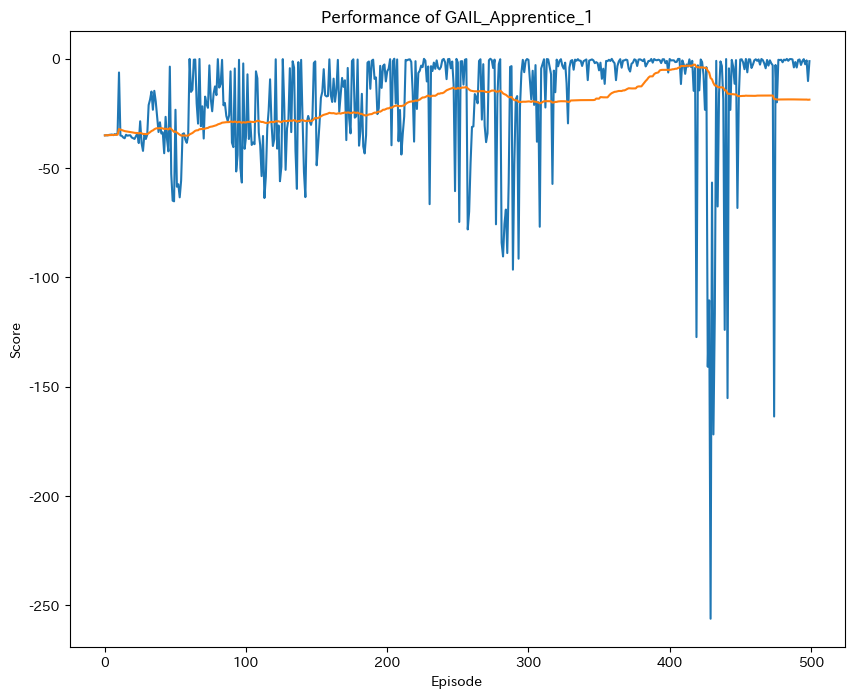

GAIL Apprentice 1 saved to /home/shimoiyusuke/manipulator-inverse-rl/Compare/Models/GAIL/Apprentice_1

--- GAIL Apprentice 1 Stats (per 50 episodes) ---
Chunk  Range           Success    Fail       Rate      
------------------------------------------------------------
0      0-49            3.0        47.0         6.00%
1      50-99           12.0       38.0        24.00%
2      100-149         14.0       36.0        28.00%
3      150-199         26.0       24.0        52.00%
4      200-249         44.0       6.0         88.00%
5      250-299         30.0       20.0        60.00%
6      300-349         49.0       1.0         98.00%
7      350-399         50.0       0.0        100.00%
8      400-449         41.0       9.0         82.00%
9      450-499         49.0       1.0         98.00%



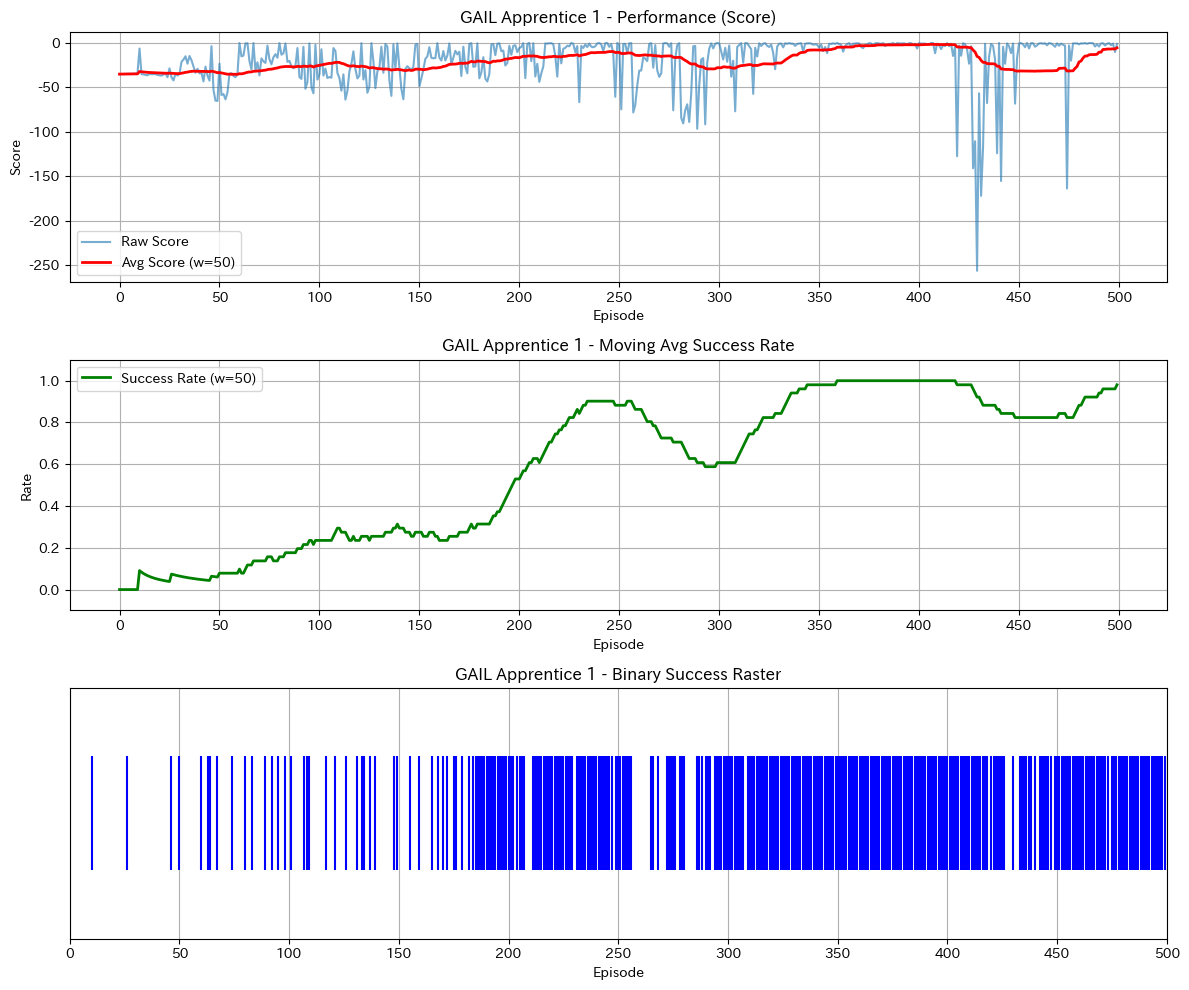


  GAIL Apprentice 2 Training



学習中..:  10%|█         | 52/500 [00:16<01:48,  4.14it/s]

Episode: 50 	 Steps: 50 	 Score: -59.5 	 Avg Score: -32.4 	 Success: 4/50 (8.0%)


学習中..:  20%|██        | 102/500 [00:28<01:24,  4.73it/s]

Episode: 100 	 Steps: 25 	 Score: -19.1 	 Avg Score: -32.1 	 Success: 19/50 (38.0%)


...

学習中..:  80%|████████  | 402/500 [01:13<00:11,  8.27it/s]

Episode: 400 	 Steps: 4 	 Score: -2.0 	 Avg Score: -4.3 	 Success: 50/50 (100.0%)


学習中..:  90%|█████████ | 452/500 [01:19<00:05,  8.41it/s]

Episode: 450 	 Steps: 4 	 Score: -0.1 	 Avg Score: -2.7 	 Success: 50/50 (100.0%)


学習中..: 100%|██████████| 500/500 [01:25<00:00,  5.88it/s]


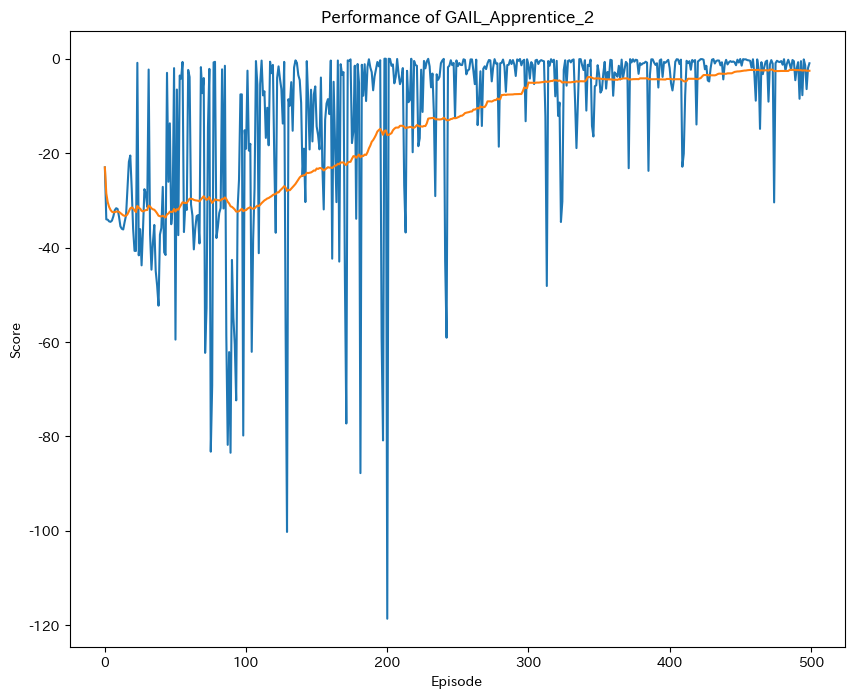

GAIL Apprentice 2 saved to /home/shimoiyusuke/manipulator-inverse-rl/Compare/Models/GAIL/Apprentice_2

--- GAIL Apprentice 2 Stats (per 50 episodes) ---
Chunk  Range           Success    Fail       Rate      
------------------------------------------------------------
0      0-49            5.0        45.0        10.00%
1      50-99           18.0       32.0        36.00%
2      100-149         31.0       19.0        62.00%
3      150-199         41.0       9.0         82.00%
4      200-249         45.0       5.0         90.00%
5      250-299         50.0       0.0        100.00%
6      300-349         50.0       0.0        100.00%
7      350-399         50.0       0.0        100.00%
8      400-449         50.0       0.0        100.00%
9      450-499         50.0       0.0        100.00%



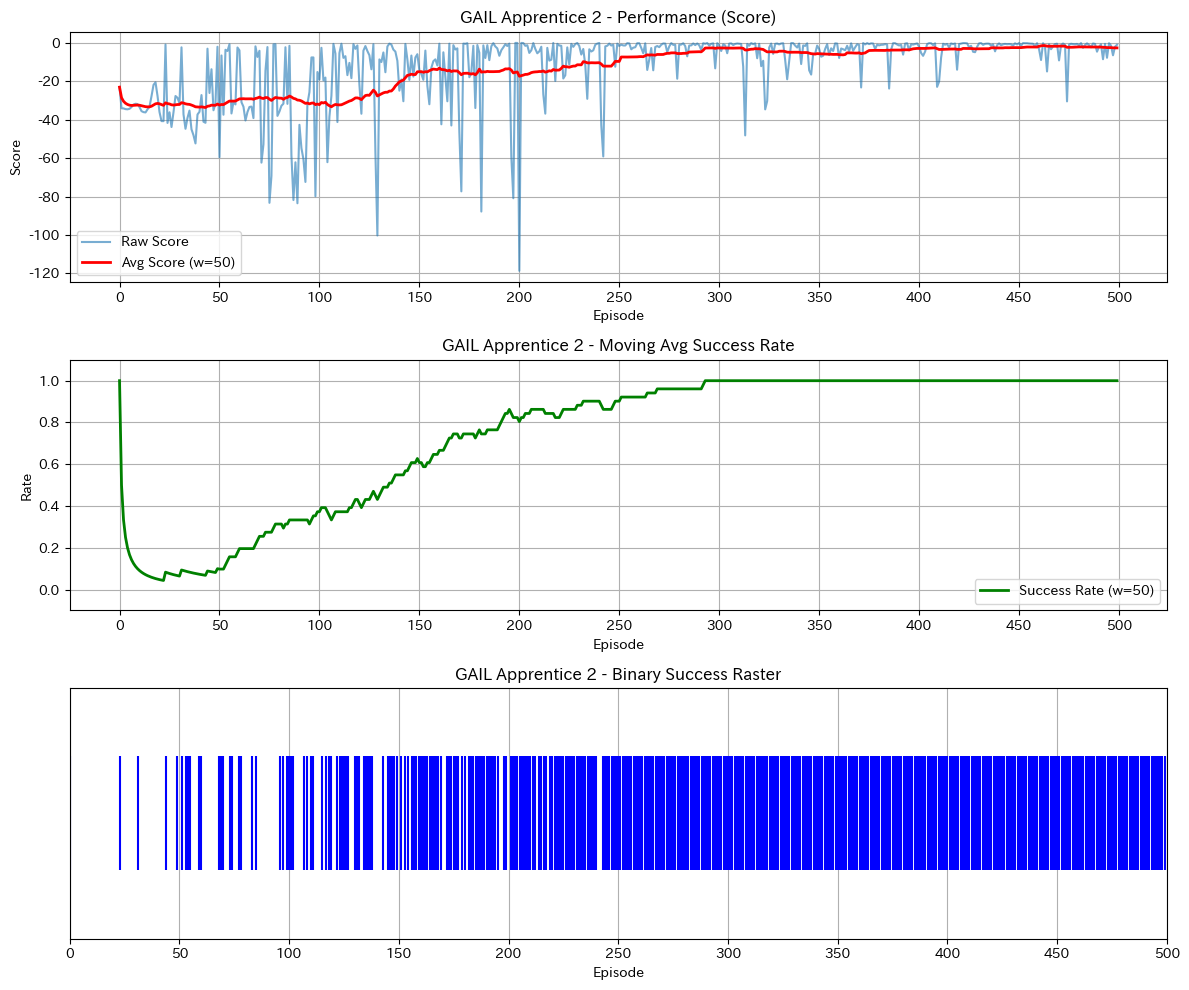


  GAIL Apprentice 3 Training



学習中..:  10%|█         | 51/500 [00:17<02:27,  3.05it/s]

Episode: 50 	 Steps: 50 	 Score: -73.4 	 Avg Score: -36.6 	 Success: 0/50 (0.0%)


学習中..:  20%|██        | 101/500 [00:32<01:39,  3.99it/s]

Episode: 100 	 Steps: 3 	 Score: -0.7 	 Avg Score: -32.2 	 Success: 6/50 (12.0%)


...

学習中..:  80%|████████  | 402/500 [01:32<00:12,  7.90it/s]

Episode: 400 	 Steps: 2 	 Score: -1.0 	 Avg Score: -17.4 	 Success: 50/50 (100.0%)


学習中..:  90%|█████████ | 452/500 [01:38<00:05,  8.80it/s]

Episode: 450 	 Steps: 1 	 Score: -0.3 	 Avg Score: -2.5 	 Success: 50/50 (100.0%)


学習中..: 100%|██████████| 500/500 [01:44<00:00,  4.80it/s]


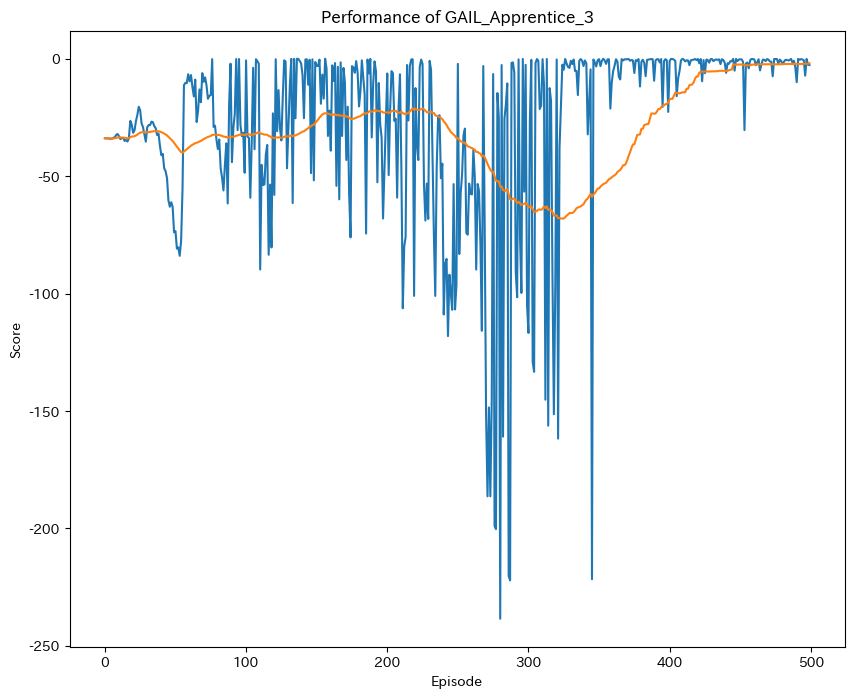

GAIL Apprentice 3 saved to /home/shimoiyusuke/manipulator-inverse-rl/Compare/Models/GAIL/Apprentice_3

--- GAIL Apprentice 3 Stats (per 50 episodes) ---
Chunk  Range           Success    Fail       Rate      
------------------------------------------------------------
0      0-49            0.0        50.0         0.00%
1      50-99           5.0        45.0        10.00%
2      100-149         21.0       29.0        42.00%
3      150-199         35.0       15.0        70.00%
4      200-249         17.0       33.0        34.00%
5      250-299         18.0       32.0        36.00%
6      300-349         40.0       10.0        80.00%
7      350-399         50.0       0.0        100.00%
8      400-449         50.0       0.0        100.00%
9      450-499         50.0       0.0        100.00%



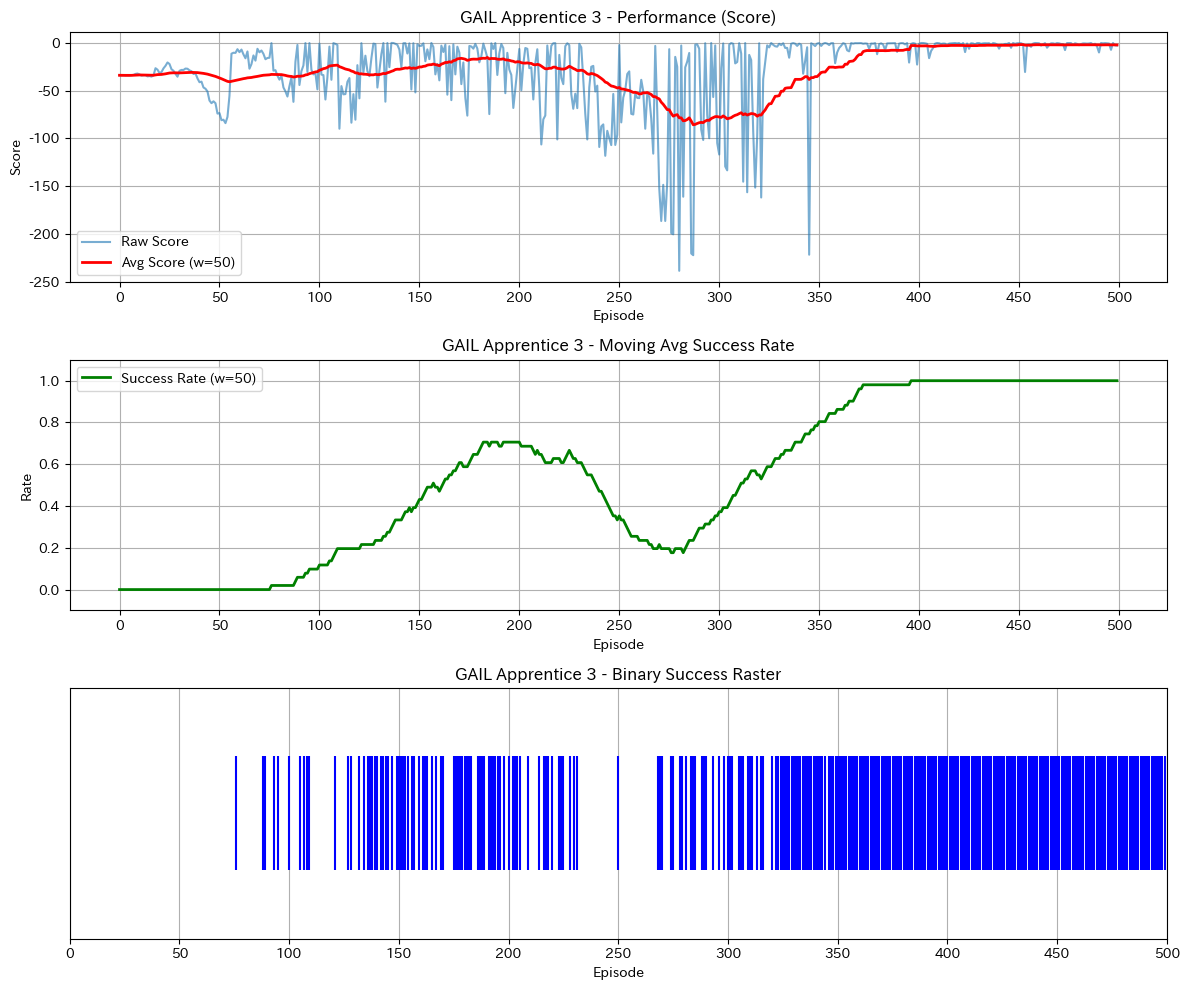

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/GAIL/GAIL_Apprentice_Comparison_Performance.png


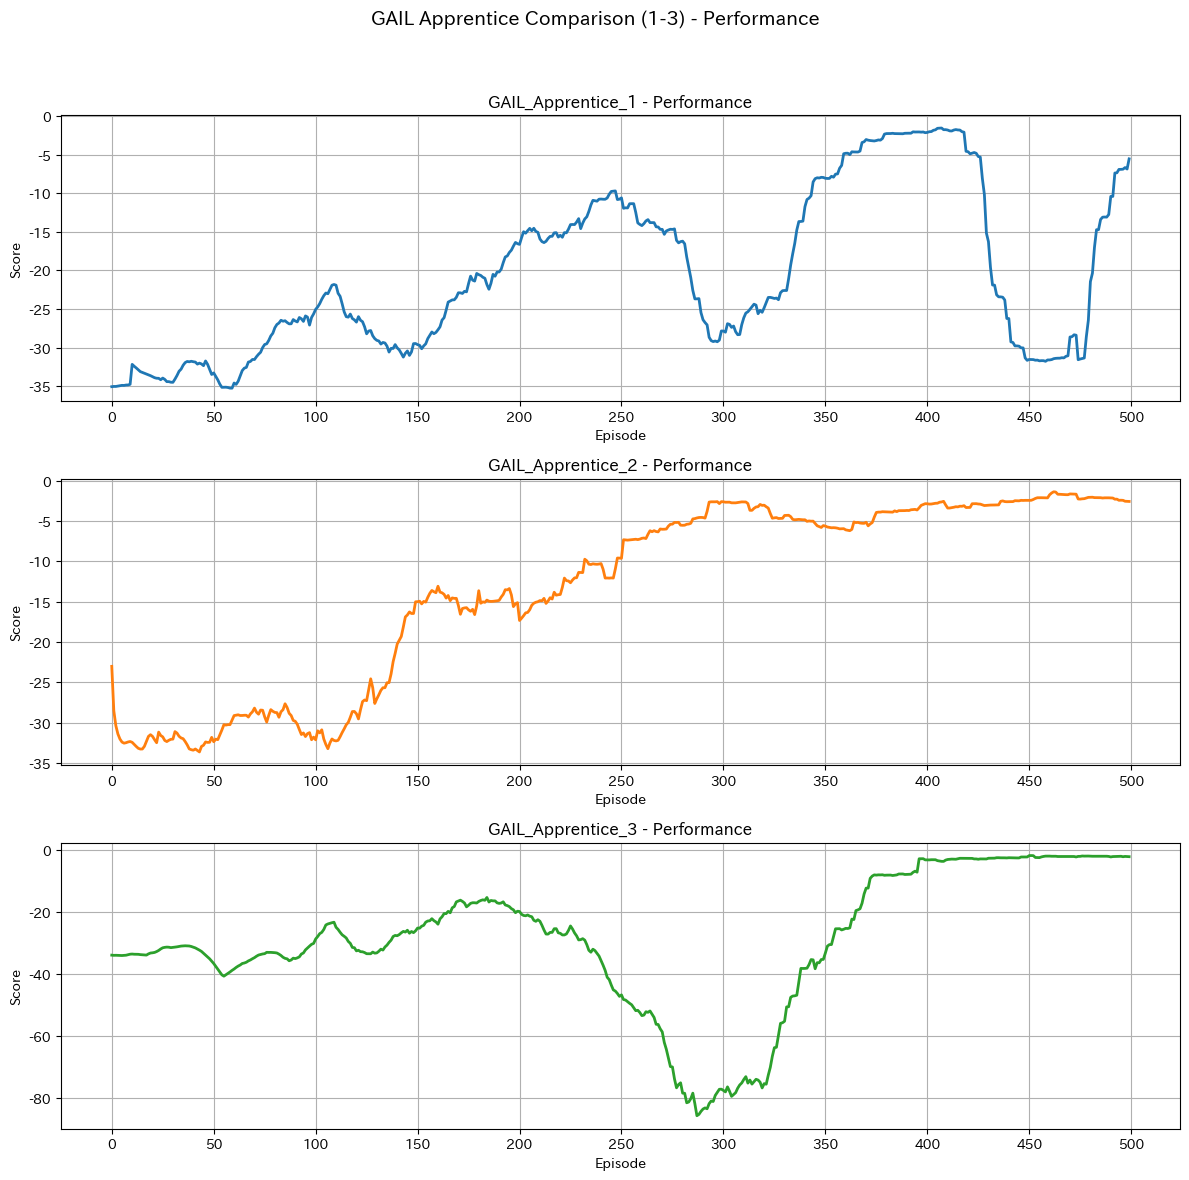

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/GAIL/GAIL_Apprentice_Comparison_Success.png


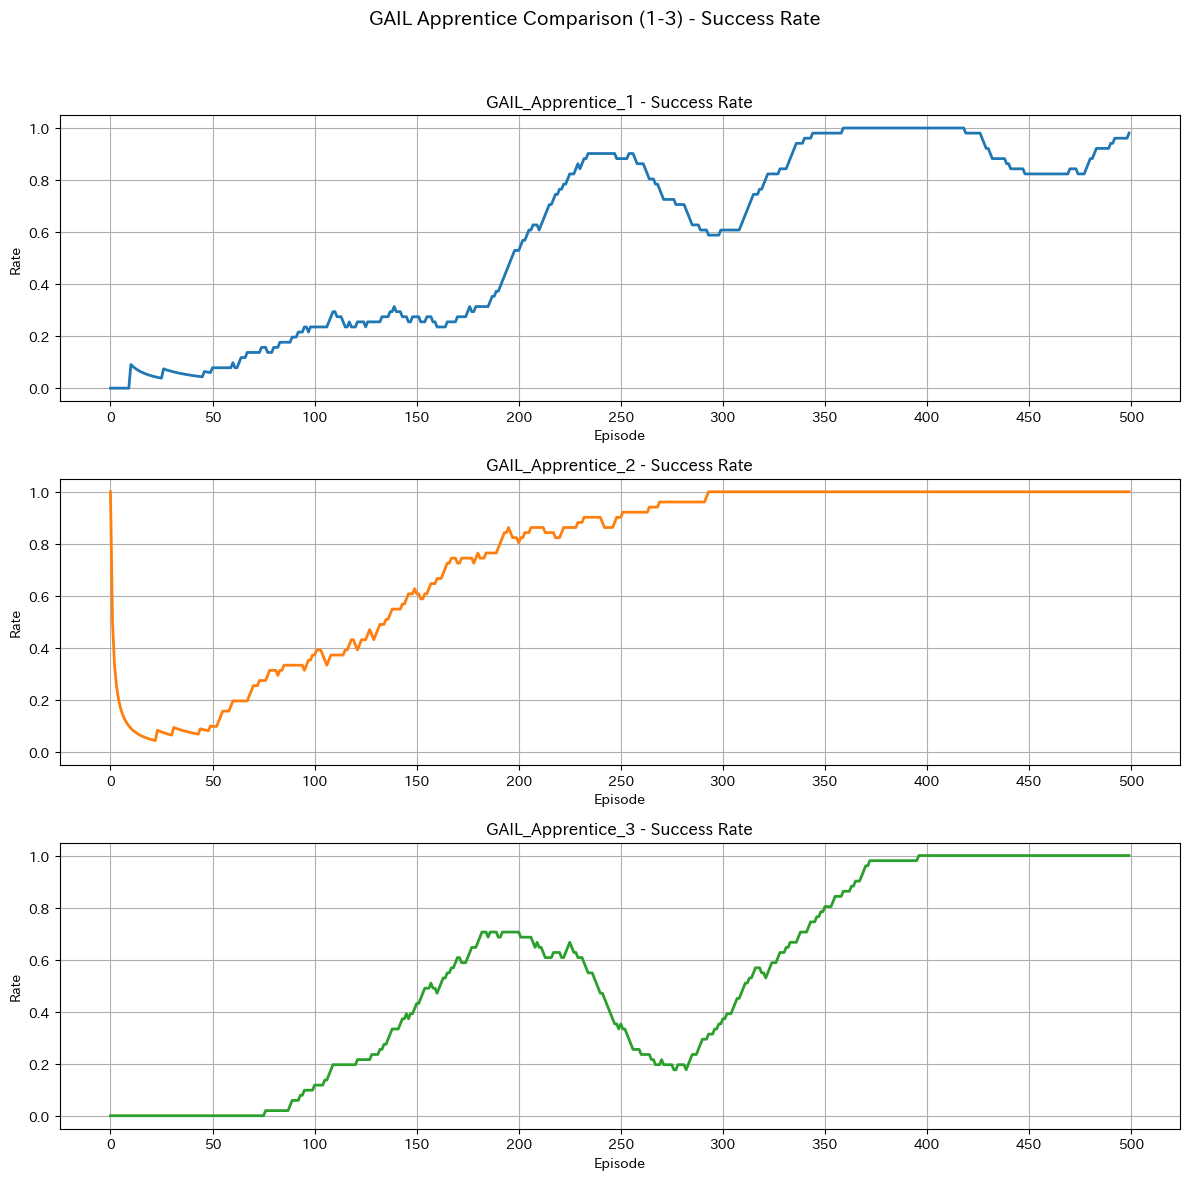

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/GAIL/GAIL_Apprentice_Comparison_Raster.png


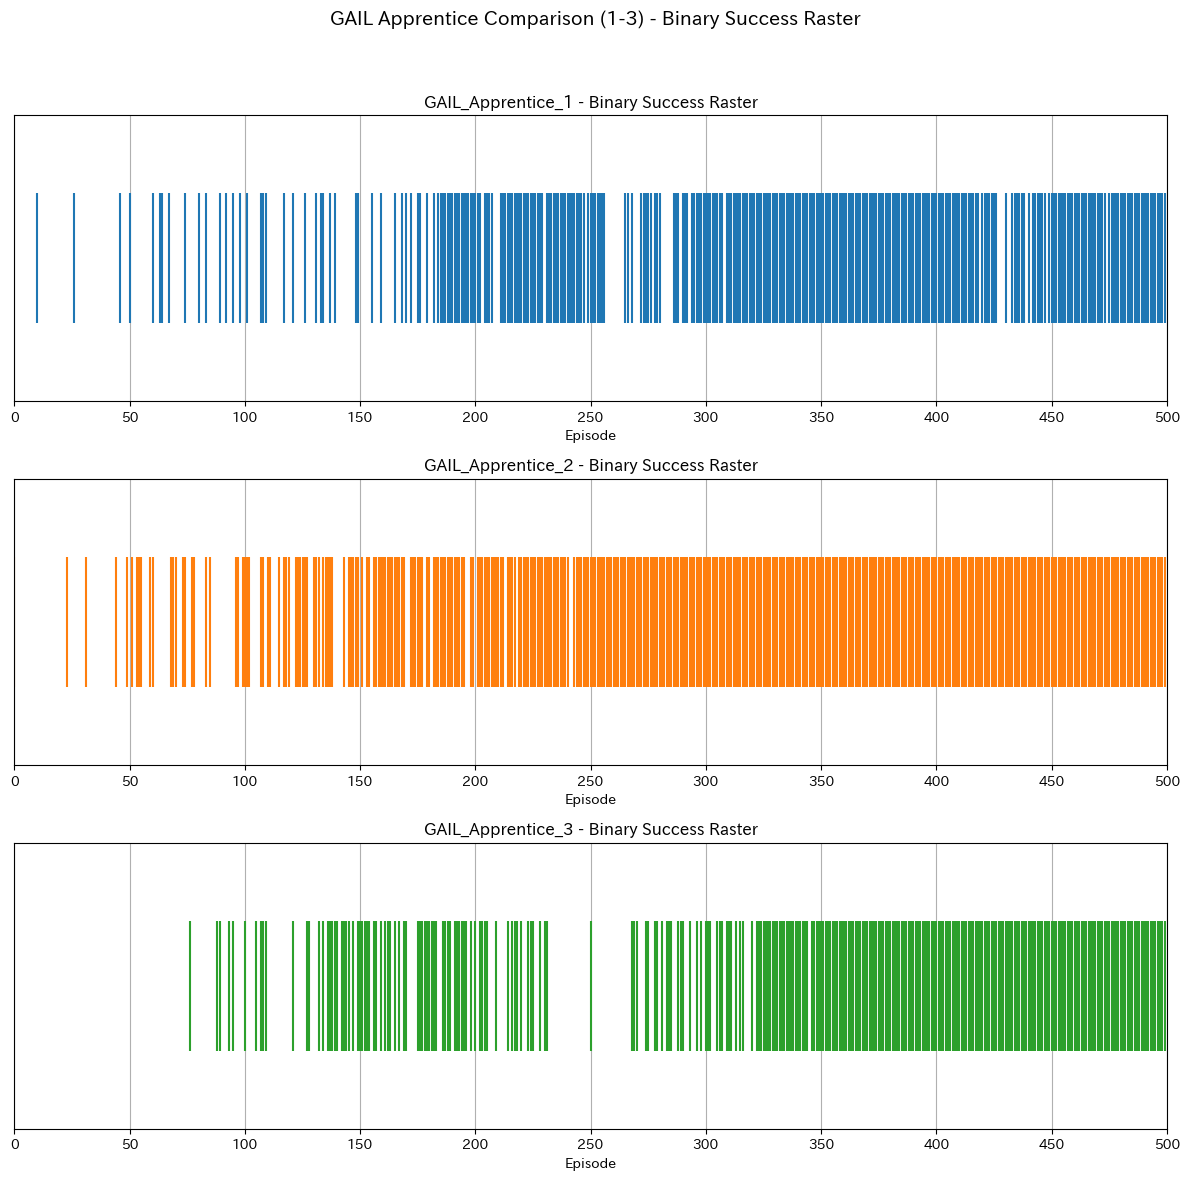

numActiveThreads = 0
stopping threads
Thread with taskId 0 exiting
Thread TERMINATED
destroy semaphore
semaphore destroyed
destroy main semaphore
main semaphore destroyed
finished
numActiveThreads = 0
btShutDownExampleBrowser stopping threads
Thread with taskId 0 exiting
Thread TERMINATED
destroy semaphore
semaphore destroyed
destroy main semaphore
main semaphore destroyed


In [7]:
# Train GAIL Apprentices 1-3
gail_apprentice_train_data = gail_runner.train_apprentices()

## 7. GAIL Apprentice Evaluation


### GAIL Apprentice Evaluation Algorithm

Each trained GAIL Apprentice agent (1 to 3) is evaluated over $N=500$ episodes.

**1. Stochastic Policy:**
Evaluations use the same stochastic exploration policy (Gaussian noise) as TD3 apprentices for fairness:
$$ a_t = \text{clip}(\pi_{\theta_{\text{gail}}}(s_t) + \epsilon, a_{\text{min}}, a_{\text{max}}), \quad \epsilon \sim \mathcal{N}(0, 0.1) $$

**2. Metrics:**
- **Mean Return:** Average cumulative reward (from the *original environment*, not the GAIL discriminator reward).
  $$ \bar{G} = \frac{1}{N} \sum_{i=1}^N G_i $$

- **Success Rate:** Percentage of successful episodes.
  $$ S = \frac{1}{N} \sum_{i=1}^N \mathbb{I}(\text{success}^{(i)}) \times 100 $$

**Symbol Definitions:**
- $N$: Number of evaluation episodes (500)
- $\pi_{\theta_{\text{gail}}}$: GAIL policy parameterised by $\theta_{\text{gail}}$
- $\epsilon$: Exploration noise $\mathcal{N}(0, 0.1)$
- $G_i$: Cumulative return of episode $i$
- $\mathbb{I}(\cdot)$: Indicator function



In [8]:
# Evaluate GAIL Apprentices
gail_apprentice_eval_data = gail_runner.evaluate_apprentices()

argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color_green=0.21176470816135406
argv[2]=--background_color_blue=0.1764705926179886
Using cached expert trajectories from /home/shimoiyusuke/manipulator-inverse-rl/Compare/expert_trajectories.pt
startThreads creating 1 threads.
starting thread 0
started thread 0 
argc=5
argv[0] = --unused
argv[1] = --background_color_red=0.8745098114013672
argv[2] = --background_color_green=0.21176470816135406
argv[3] = --background_color_blue=0.1764705926179886
argv[4] = --start_demo_name=Physics Server
ExampleBrowserThreadFunc started
X11 functions dynamically loaded using dlopen/dlsym OK!
X11 functions dynamically loaded using dlopen/dlsym OK!
Creating context
Created GL 3.3 context
Direct GLX rendering context obtained
Making context current
GL_VENDOR=Mesa
GL_RENDERER=llvmpipe (LLVM 20.1.2, 256 bits)
GL_VERSION=4.5 (Core Profile) Mesa 25.0.7-0ubuntu0.24.04.2
GL_SHADING_LANGUAGE_VERSION=4.50
pthread_getconcurrency()=0
Version = 4.

Evaluating:   0%|          | 0/500 [00:00<?, ?it/s]

ven = Mesa


Evaluating: 100%|██████████| 500/500 [00:16<00:00, 30.96it/s]


GAIL Apprentice 1 Evaluation: Mean Return = -2.514, Success: 498/500 (99.6%)

--- GAIL Apprentice 1 (Eval) Stats (per 50 episodes) ---
Chunk  Range           Success    Fail       Rate      
------------------------------------------------------------
0      0-49            50         0          100.00%
1      50-99           50         0          100.00%
2      100-149         49         1           98.00%
3      150-199         50         0          100.00%
4      200-249         50         0          100.00%
5      250-299         50         0          100.00%
6      300-349         50         0          100.00%
7      350-399         49         1           98.00%
8      400-449         50         0          100.00%
9      450-499         50         0          100.00%


--- Evaluating GAIL Apprentice 2 ---
Evaluating agent for 500 episodes...


Evaluating: 100%|██████████| 500/500 [00:13<00:00, 36.58it/s]


GAIL Apprentice 2 Evaluation: Mean Return = -2.140, Success: 500/500 (100.0%)

--- GAIL Apprentice 2 (Eval) Stats (per 50 episodes) ---
Chunk  Range           Success    Fail       Rate      
------------------------------------------------------------
0      0-49            50         0          100.00%
1      50-99           50         0          100.00%
2      100-149         50         0          100.00%
3      150-199         50         0          100.00%
4      200-249         50         0          100.00%
5      250-299         50         0          100.00%
6      300-349         50         0          100.00%
7      350-399         50         0          100.00%
8      400-449         50         0          100.00%
9      450-499         50         0          100.00%


--- Evaluating GAIL Apprentice 3 ---
Evaluating agent for 500 episodes...


Evaluating: 100%|██████████| 500/500 [00:13<00:00, 37.25it/s]


GAIL Apprentice 3 Evaluation: Mean Return = -2.232, Success: 500/500 (100.0%)

--- GAIL Apprentice 3 (Eval) Stats (per 50 episodes) ---
Chunk  Range           Success    Fail       Rate      
------------------------------------------------------------
0      0-49            50         0          100.00%
1      50-99           50         0          100.00%
2      100-149         50         0          100.00%
3      150-199         50         0          100.00%
4      200-249         50         0          100.00%
5      250-299         50         0          100.00%
6      300-349         50         0          100.00%
7      350-399         50         0          100.00%
8      400-449         50         0          100.00%
9      450-499         50         0          100.00%

numActiveThreads = 0
stopping threads
Thread with taskId 0 exiting
Thread TERMINATED
destroy semaphore
semaphore destroyed
destroy main semaphore
main semaphore destroyed
finished
numActiveThreads = 0
btShutDownExamp

## 8. GAIL Comparative Plots


### GAIL Comparative Analysis

This section compares the **TD3 Expert** (Baseline) against the **GAIL Apprentices (1-3)**.
GAIL apprentices learn directly from expert state-action pairs without a manually defined reward function.

**1. Metrics Visualization:**
We use the same metrics as in the TD3 comparison for consistency:
- **Smoothed Score:** Moving average of true environment returns ($w=50$).
  $$ \bar{G}_t = \frac{1}{w} \sum_{i=0}^{w-1} G_{t-i} $$
- **Success Rate:** Moving average of success rate.

**2. Analysis Points:**
- **Sample Efficiency:** How quickly do GAIL apprentices reach expert performance?
- **Robustness:** Does the adversarial training lead to stable policies?

**Symbol Definitions:**
- $\bar{G}_t$: Smoothed return
- $w$: Window size (50)



Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/GAIL/GAIL_Learning_Comparison_Performance.png


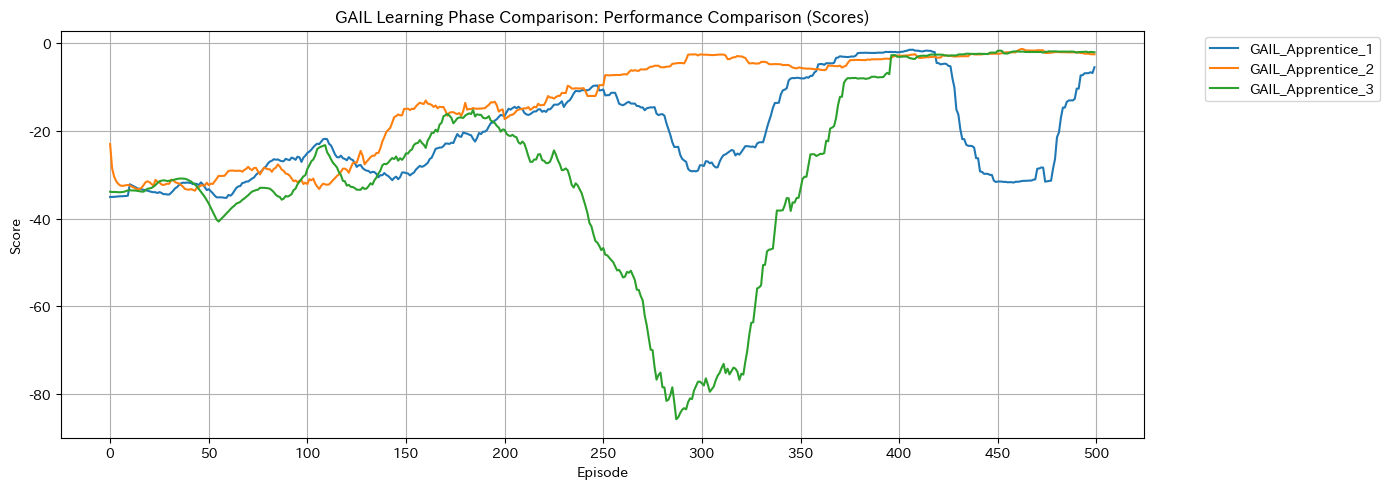

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/GAIL/GAIL_Learning_Comparison_SuccessRate.png


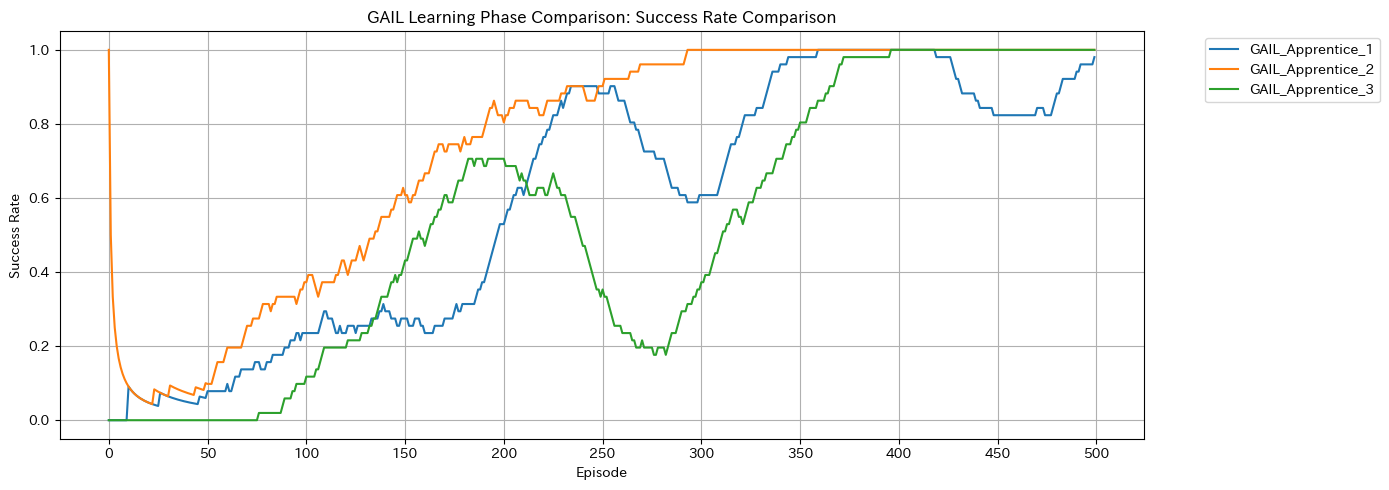

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/GAIL/GAIL_Learning_Comparison_Raster.png


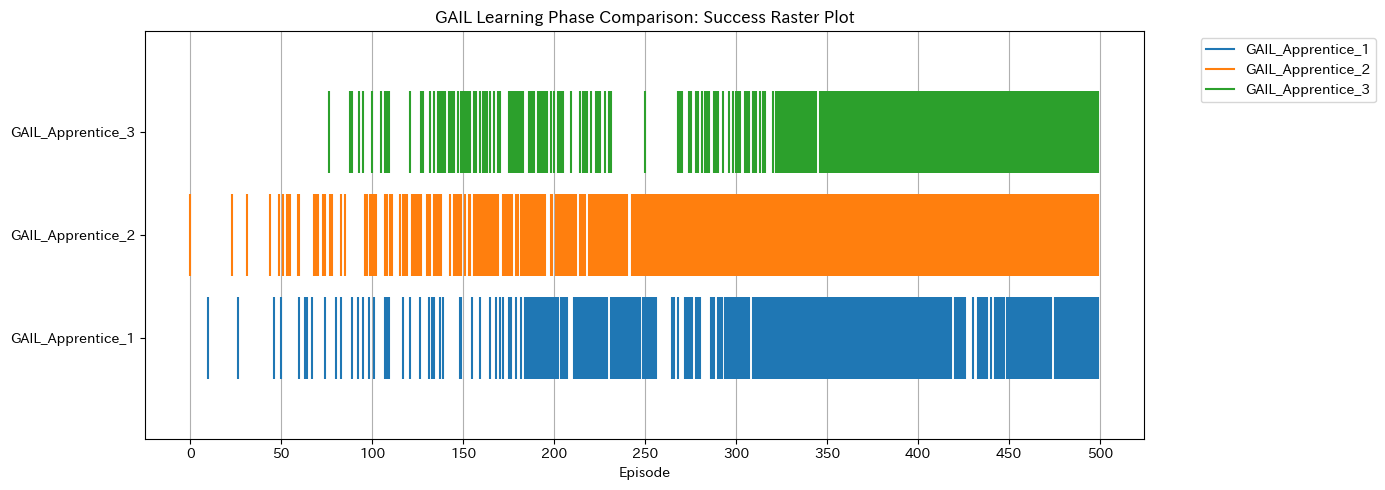

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/GAIL/GAIL_Apprentice_Comparison_Performance.png


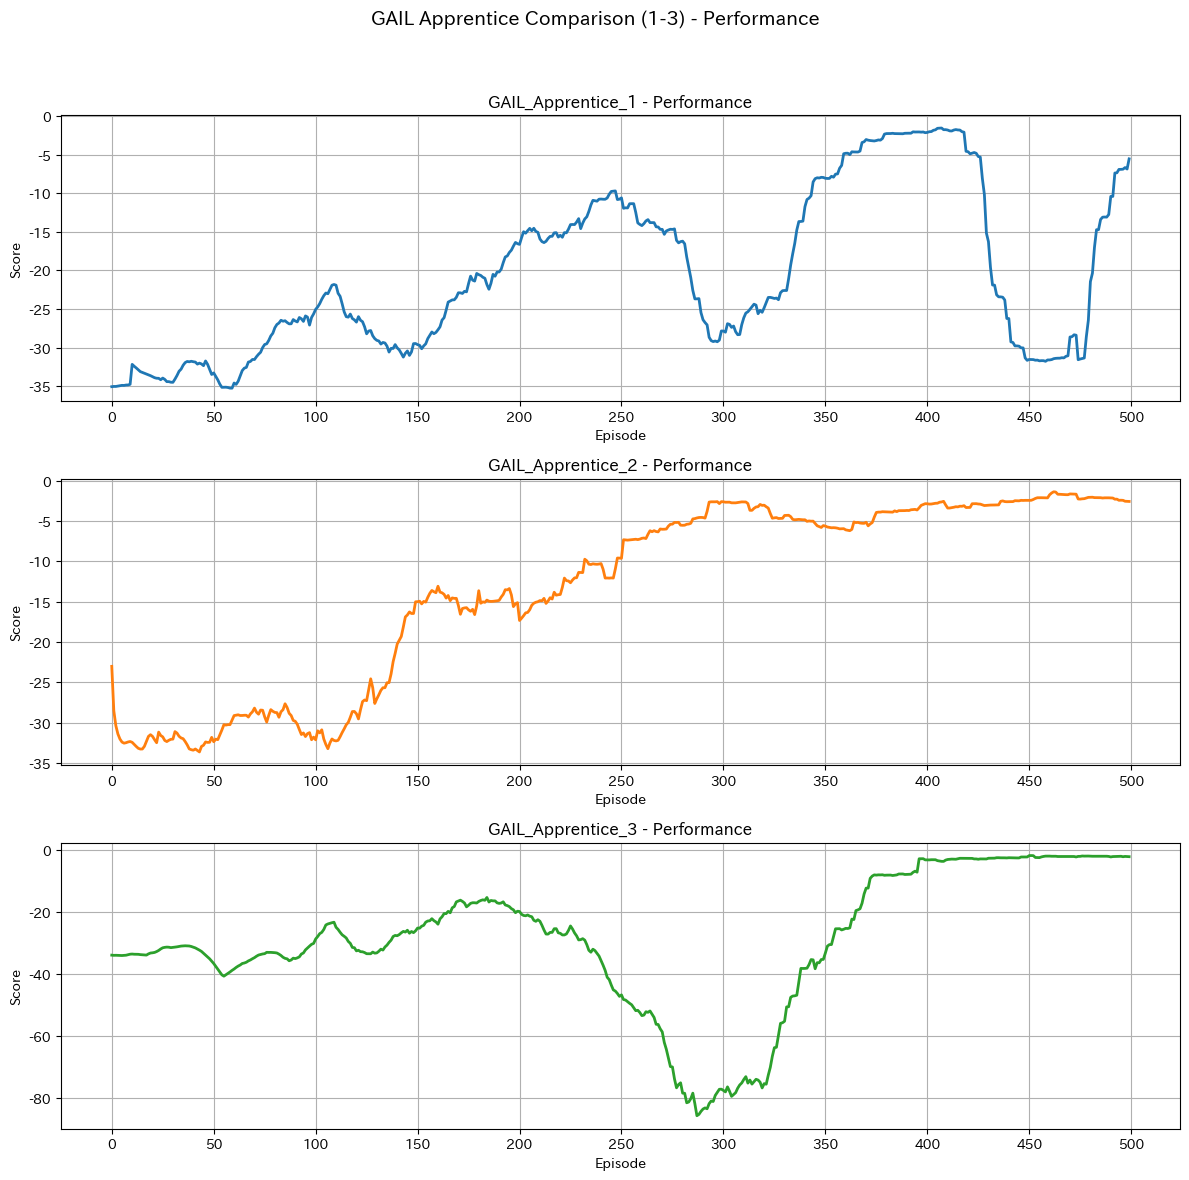

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/GAIL/GAIL_Apprentice_Comparison_Success.png


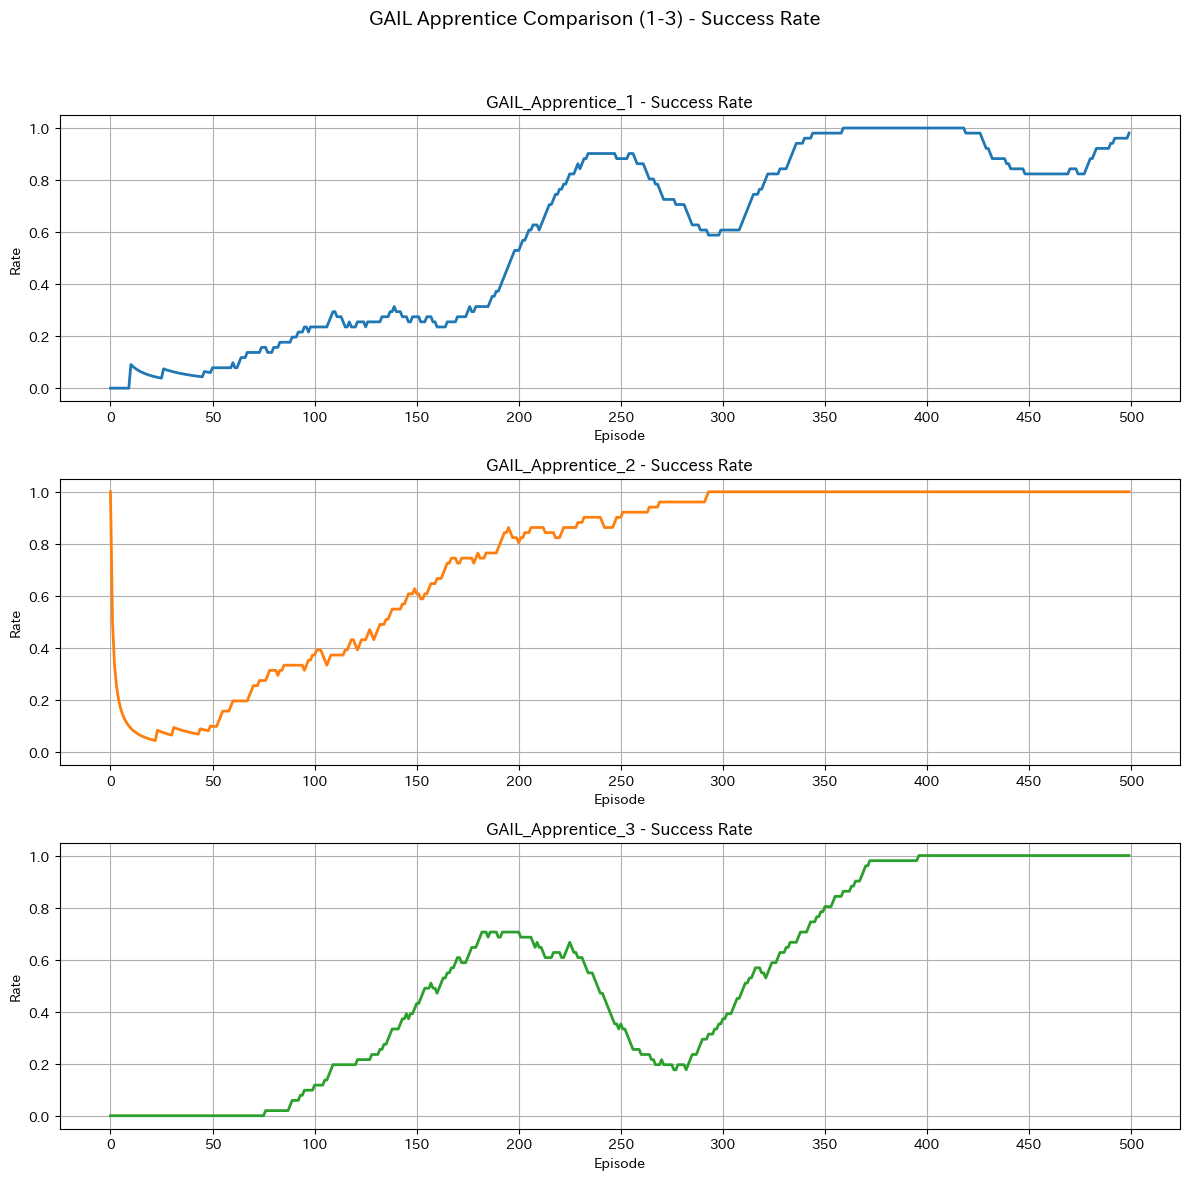

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/GAIL/GAIL_Apprentice_Comparison_Raster.png


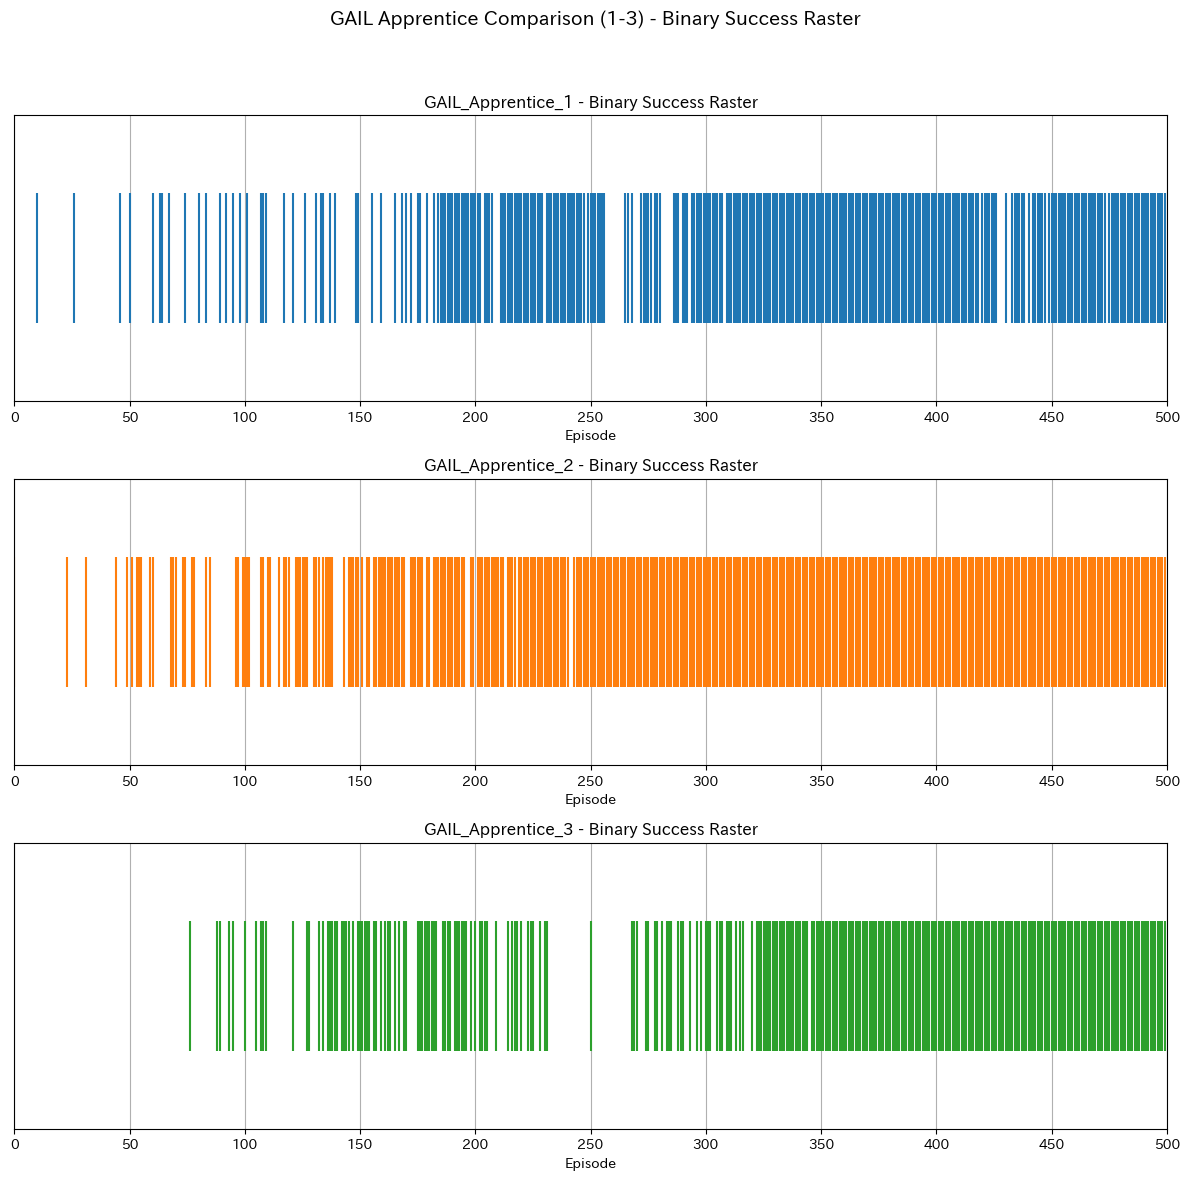

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/GAIL/GAIL_Evaluation_Comparison_Performance.png


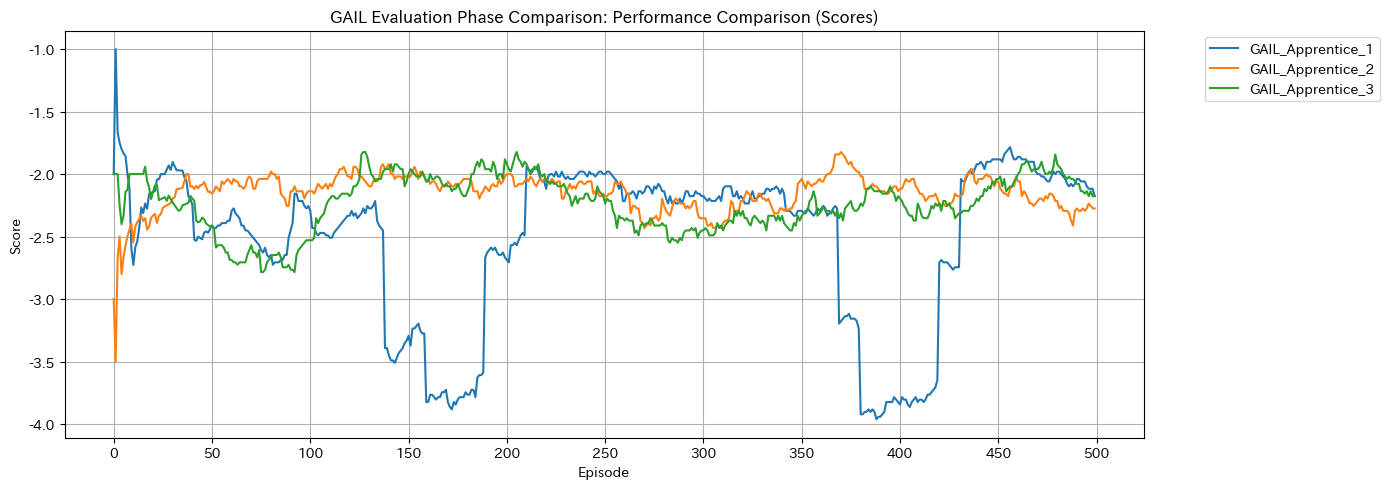

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/GAIL/GAIL_Evaluation_Comparison_SuccessRate.png


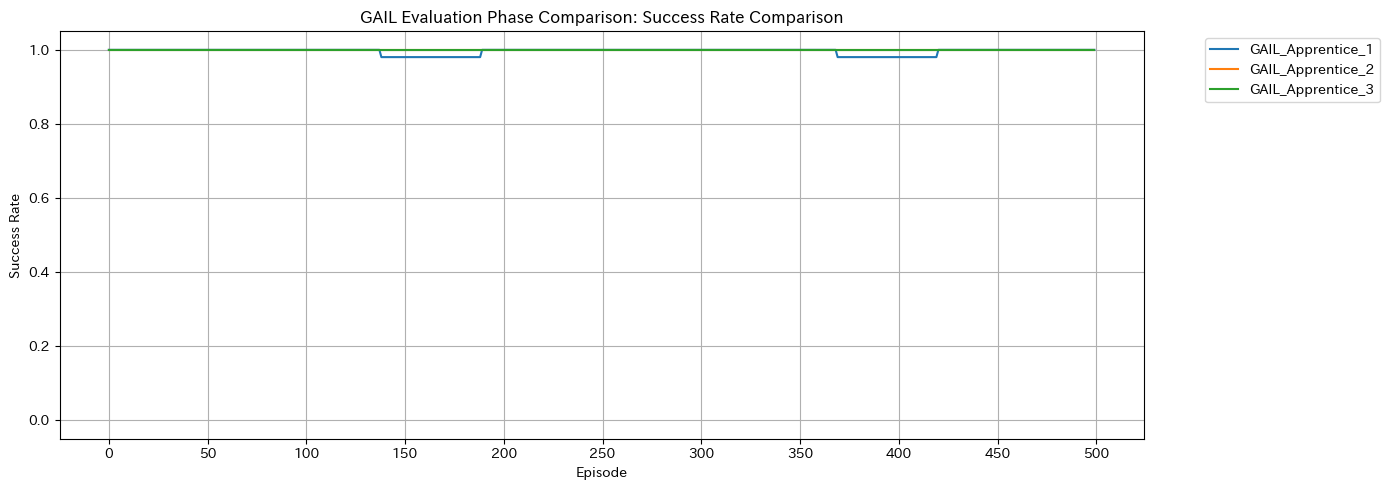

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/GAIL/GAIL_Evaluation_Comparison_Raster.png


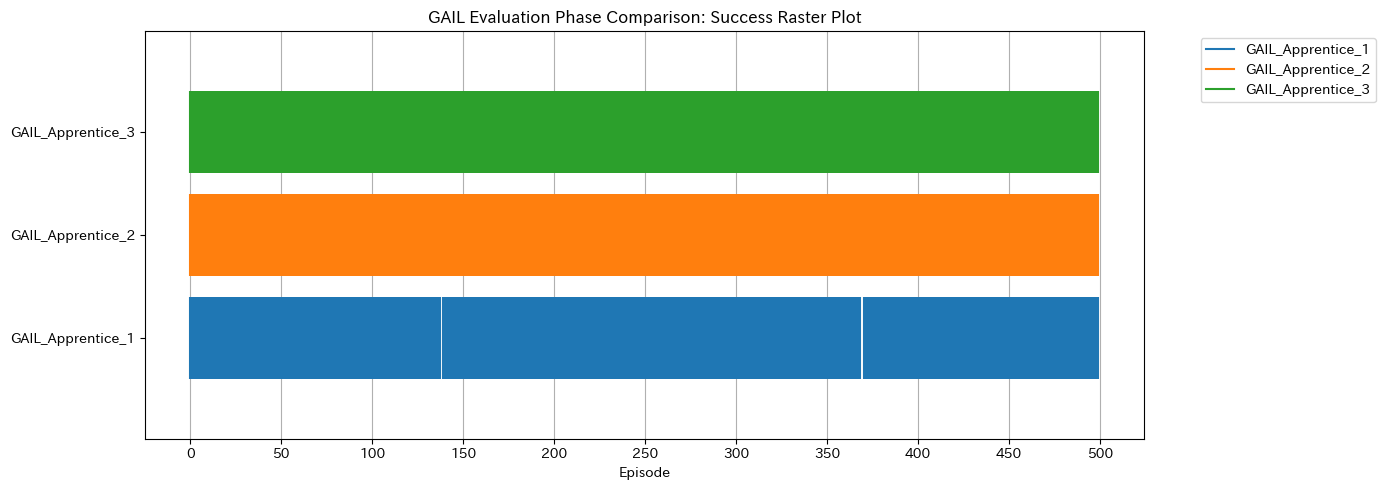

In [9]:
# Plot GAIL comparisons
gail_runner.plot_all_comparisons(
    gail_apprentice_train_data,
    gail_apprentice_eval_data
)

## 9. TD3 vs GAIL Final Comparison

This section analyzes the performance of the trained agents:

1. **Evaluation Dashboard**: Compares the evaluation metrics (return, success rate) of the TD3 Expert, TD3 Apprentices, and GAIL Apprentices.
2. **Cross-Algorithm Comparison**: Directly compares TD3 vs GAIL performance for each specific Apprentice index.


### Visual Analysis & Metrics

To analyze and compare the stability and performance of the trained agents (`TD3 Expert`, `Apprentices 1-3`), we visualize the following metrics using comparative dashboards.

**1. Smoothing (Moving Average):**
To reduce variance in the raw episode returns and success rates, we apply a simple moving average (SMA) with a window formulation:
$$ \bar{x}_t = \frac{1}{w} \sum_{i=0}^{w-1} x_{t-i} $$

**2. Comparative Plots:**
- **Performance (Score):** Tracks the cumulative return per episode. Smoothed lines (solid) are overlaid on raw data (faded).
  $$ G_t = \sum_{k=0}^T r_k $$
- **Success Rate:** Tracks the binary success outcome ($ 1 $ if target reached, else $ 0 $), averaged over the window $ w $.
- **Raster Plot:** A discrete visualization where each vertical bar represents a successful episode. Dense regions indicate consistent high performance.

**Symbol Definitions:**
- $\bar{x}_t$: Smoothed value at episode $ t $
- $x_t$: Raw metric value (Return or Success) at episode $ t $
- $w$: Smoothing window size ($ w=50 $)
- $G_t$: Cumulative return (Score) for episode $ t $



In [10]:
# Compare TD3 and GAIL Apprentices
from config import TD3_RESULTS_DIR, RESULTS_DIR
import compare_utils

# Combine evaluation data
expert_data, all_apprentices = compare_utils.prepare_final_comparison_data(
    td3_expert_eval_data,
    td3_apprentice_eval_data,
    gail_apprentice_eval_data
)

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/TD3_vs_GAIL_Comparison_Performance.png


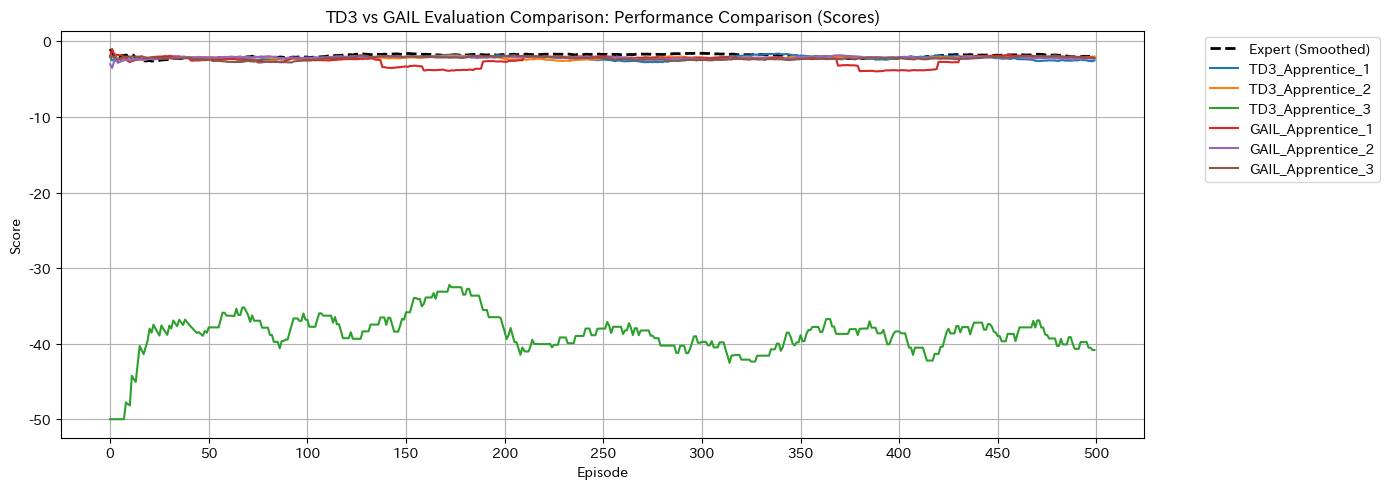

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/TD3_vs_GAIL_Comparison_SuccessRate.png


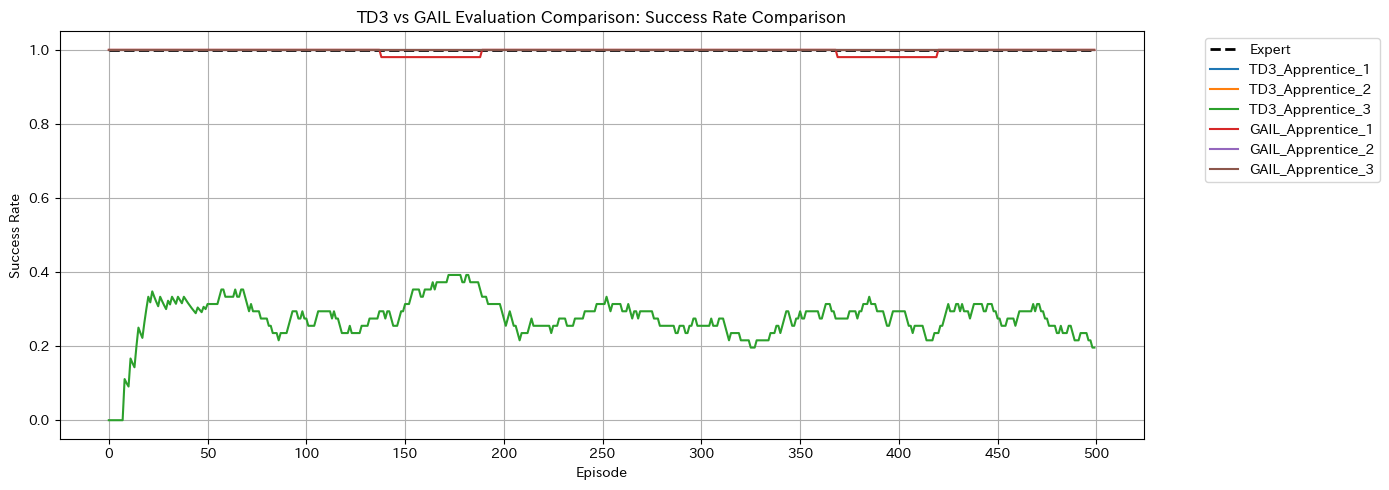

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/TD3_vs_GAIL_Comparison_Raster.png


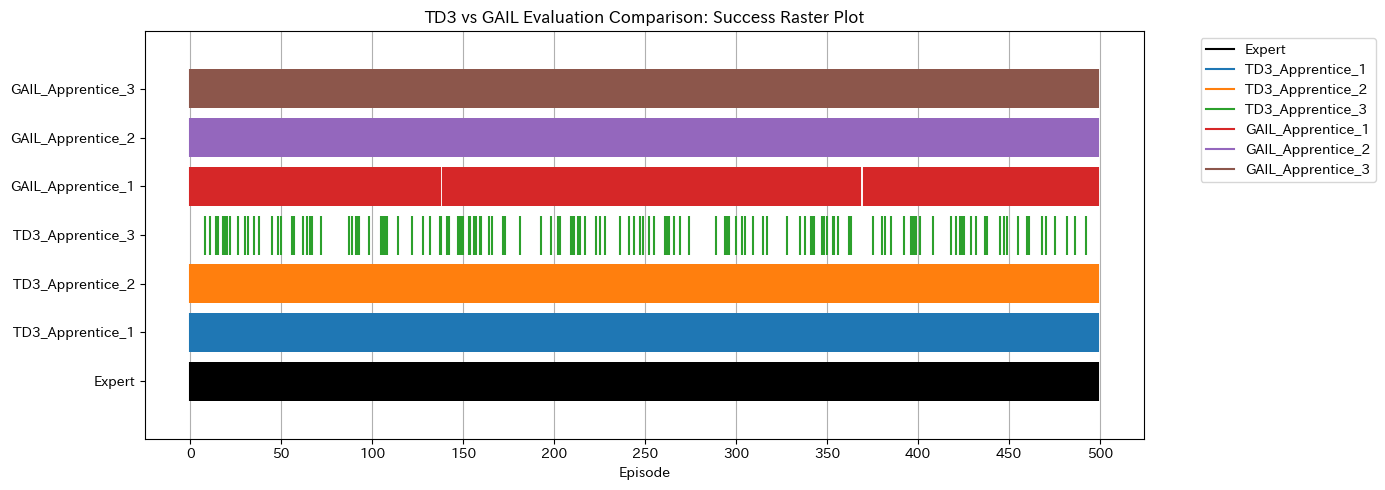

In [11]:
plot_comparative_dashboard(
    "TD3 vs GAIL Evaluation Comparison",
    expert_data,
    all_apprentices,
    save_path=str(TD3_RESULTS_DIR.parent / "TD3_vs_GAIL_Comparison.png"))

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/TD3_vs_GAIL_Training_Apprentice_1.png


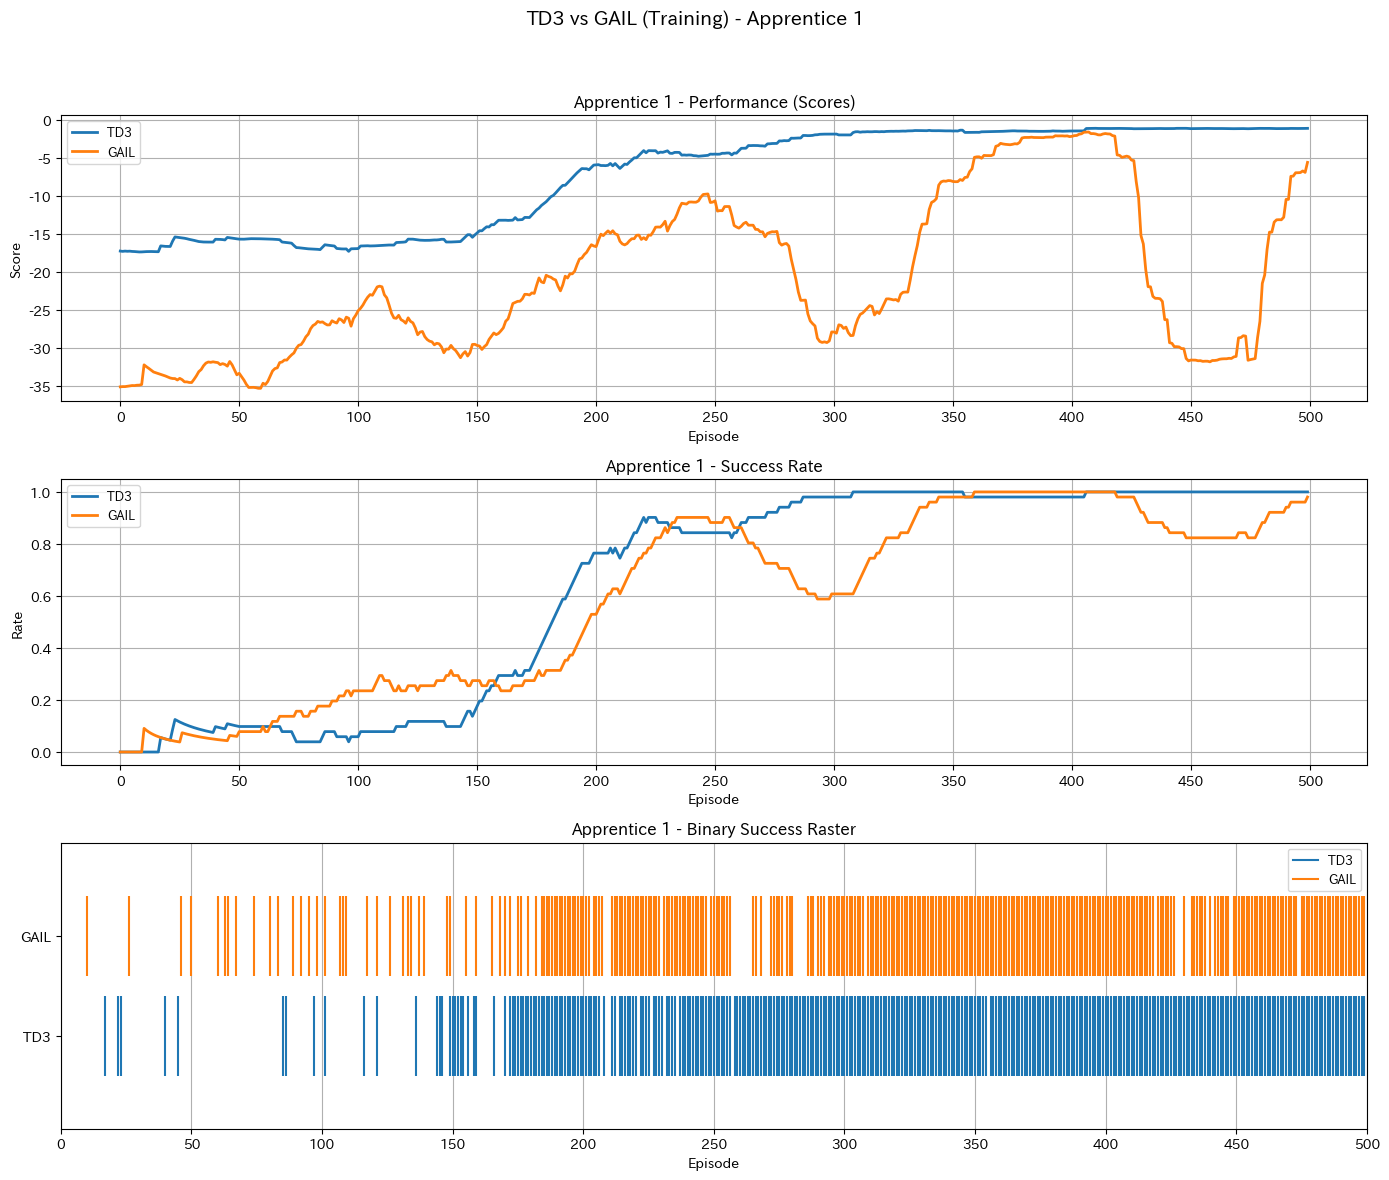

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/TD3_vs_GAIL_Training_Apprentice_2.png


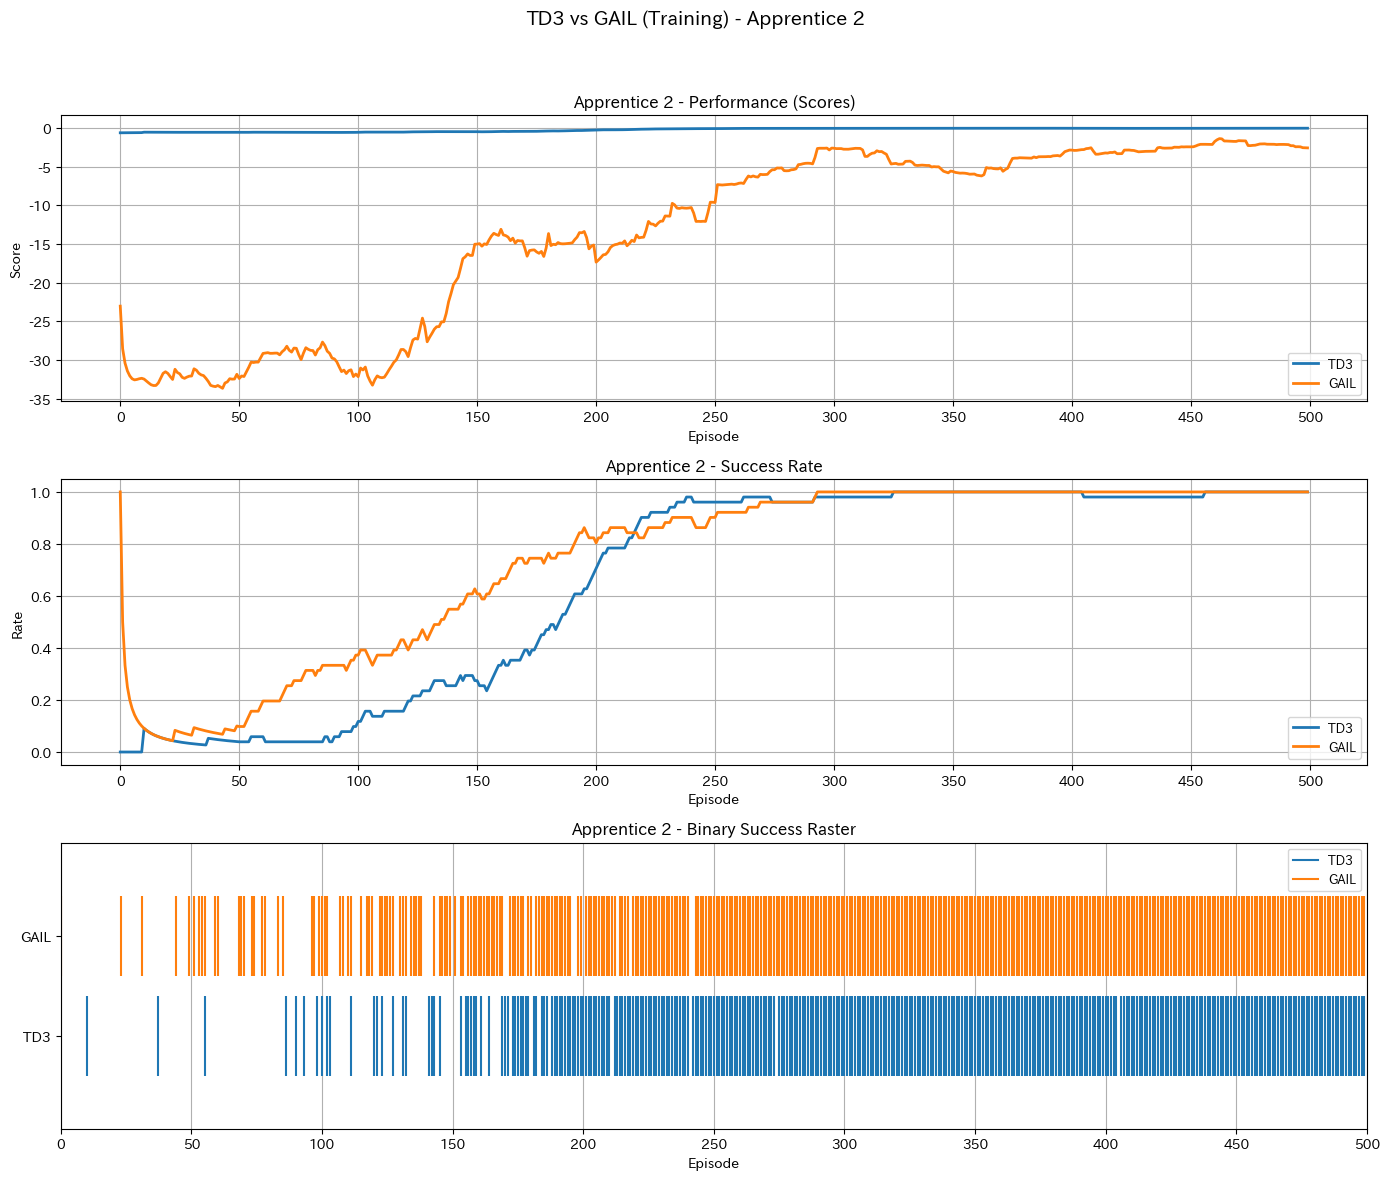

Saved /home/shimoiyusuke/manipulator-inverse-rl/Compare/Results/TD3_vs_GAIL_Training_Apprentice_3.png


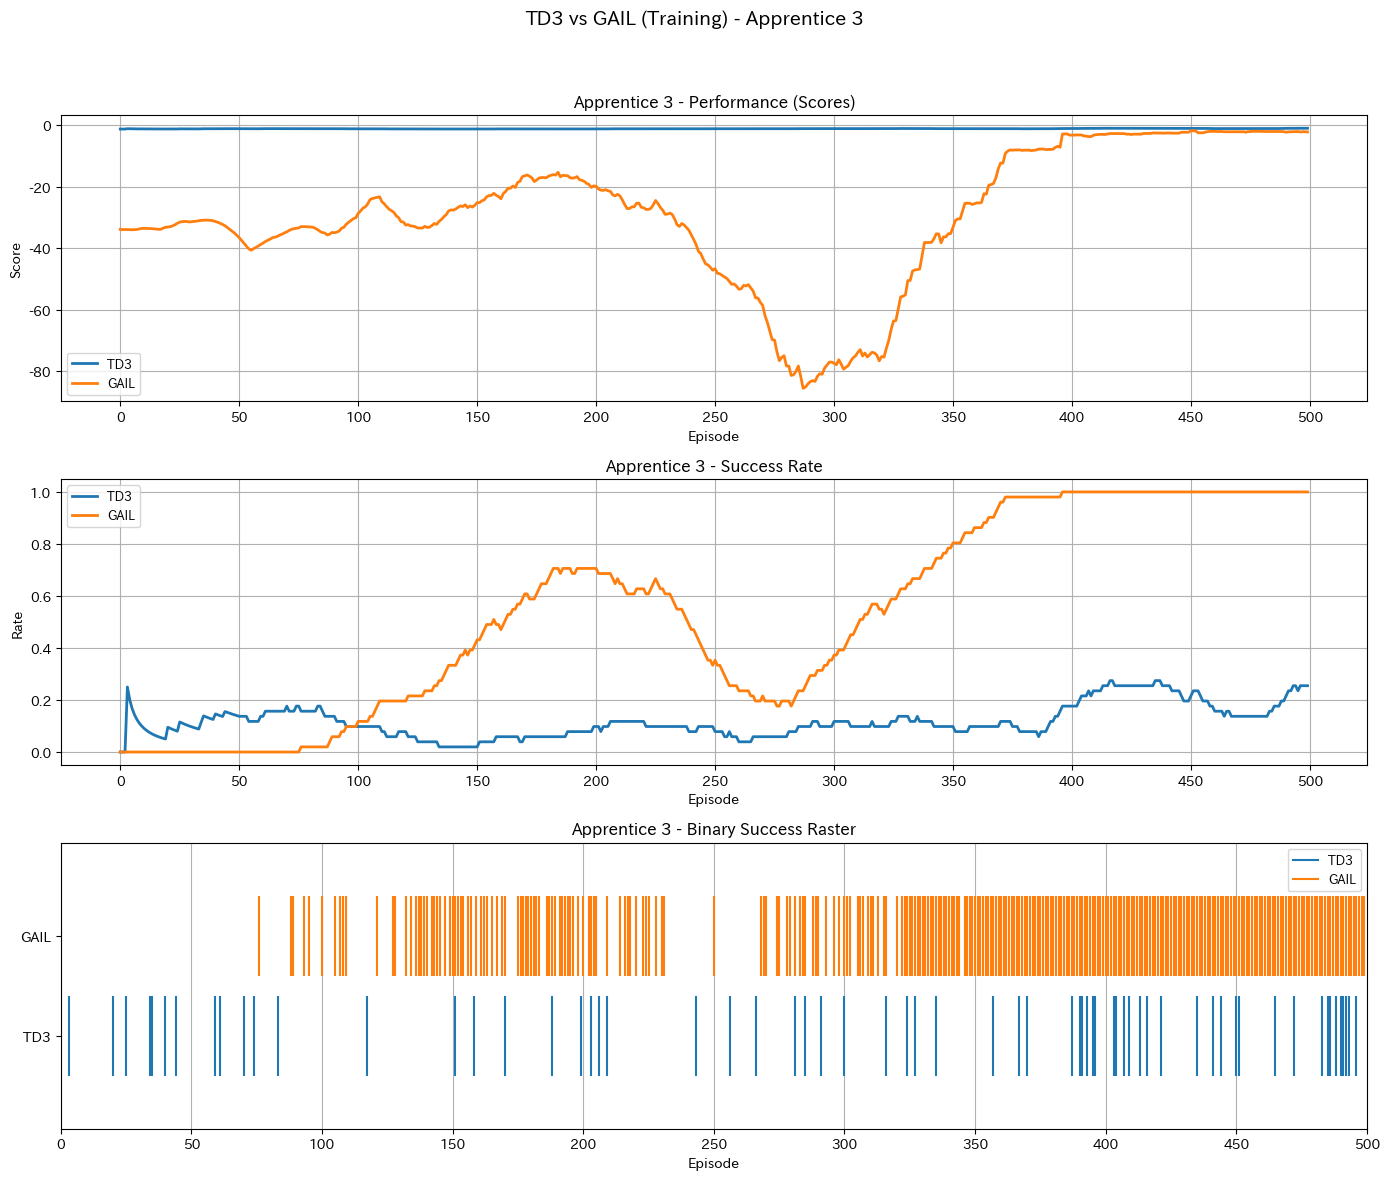

In [12]:
# Cross-algorithm comparison: TD3 vs GAIL for each Apprentice (1, 2, 3)
# Filter out Apprentice 0 from TD3 train data for cross-algorithm comparison
filtered_td3_apprentice_train_data = compare_utils.filter_apprentice_data(td3_apprentice_train_data, 'TD3_Apprentice_0')

plot_cross_algorithm_comparison(
    filtered_td3_apprentice_train_data,
    gail_apprentice_train_data,
    save_path=str(RESULTS_DIR / "TD3_vs_GAIL_Apprentice_Comparison.png")
)